#Project: Introduction to Neural Networks - ReneWind

## Wind Turbine Generator Failure Prediction

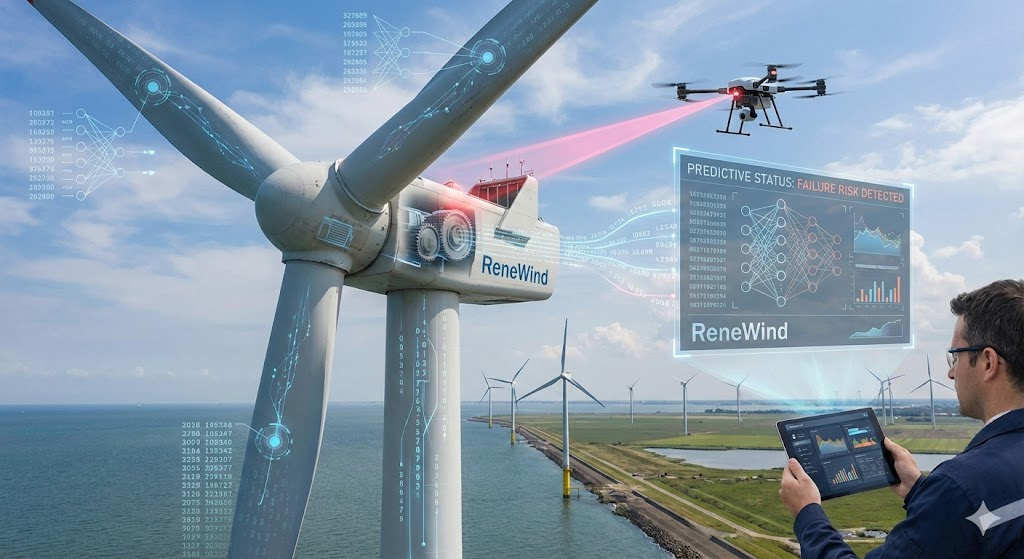

*Image generated by Gemini 3 Pro, an AI-powered tool*

### Context

Renewable energy is increasingly important in the global energy mix, and wind energy is one of the most developed technologies. The U.S. Department of Energy supports using predictive maintenance to improve operations.

Predictive maintenance uses sensor data and analytics to estimate degradation and future component performance. If failures can be predicted in advance and parts are repaired or replaced before breakdown, operation and maintenance costs can be reduced.

Sensors on wind turbines collect environmental data (temperature, humidity, wind speed, etc.) and component-specific data (gearbox, tower, blades, brake). These signals form the basis for predicting when parts are likely to fail.



### Problem Statement


**ReneWind** is a company working on improving wind energy production machinery using machine learning.

The company collected sensor data on generator failures in wind turbines. The data is ciphered for confidentiality and contains **40 predictor variables** with **20,000 training observations** and **5,000 test observations**.

The challenge is to build and tune classification models that reliably identify which generators will fail so that repairs can be planned in advance and overall maintenance costs are minimized.

The cost structure is:

- Repair (correctly predicted failures): moderate cost
- Replacement (undetected failures): highest cost
- Inspection (false alarms): lowest cost

So a model should prioritize minimizing missed failures (false negatives) over avoiding inspections (false positives).

### Objective

ReneWind's objective is to build and tune multiple classification models, evaluate their performance, and select the best model that:
- Correctly flags generators that will fail
- Allows timely repairs before breakdown
- Reduces total maintenance cost by avoiding expensive replacements,
- Favors high detection of actual failures (recall) over reducing inspections.

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) -  Failures correctly predicted by the model. These will result in repair costs.
- False negatives (FN) - Real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) - Detections where there is no failure. These will result in inspection costs.


Since replacement cost >> repair cost >> inspection cost, **minimizing False Negatives (maximizing Recall)** is critical.


**Target variable:**
1 = Failure
0 = No failure

The chosen model will be deployed to identify at-risk generators early and enable proactive maintenance at lower cost.

### Data Dictionary

The data provided is a transformed or scaled version of the original data which was collected using sensors.

We have both train and test data sets separately

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

*Both datasets consist of **40 predictor variables** and **1 target variable**.*

|||
| :------- | :------ |
| Target | Binary value of the actual prediction (holds 0 or 1) 1 - Failure, 0 - Non Failure|





### Importing the necessary libraries

In [4]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including standard scaling
from sklearn.preprocessing import StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report


#Imports the tensorflow,keras and layers.
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dense, Input, Dropout,BatchNormalization
from keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Set the seed using keras.utils.set_random_seed.
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# For TensorFlow, this will make GPU ops as deterministic as possible,
# but it can affect the overall performance
tf.config.experimental.enable_op_determinism()

### Load and View the Dataset

In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Read the train and test dataset from the drive path
train_df_main = pd.read_csv("/content/drive/MyDrive/PGP Course/Neural Networks/Project - ReneWind/Train.csv")
test_df_main = pd.read_csv("/content/drive/MyDrive/PGP Course/Neural Networks/Project - ReneWind/Test.csv")

In [8]:
# Copy main data to avoid any changes to original dataset
train_df = train_df_main.copy()
test_df = test_df_main.copy()

### Overview of the dataset

Train dataset

In [9]:
train_df.head() #By default returns top 5 records

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [10]:
train_df.tail() #By default returns bottom 5 records

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,...,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,...,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,...,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,...,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,...,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


**Observations:**

1. Anonymized Features: The columns are labeled generically as V1, V2, V3, ..., up to at least V40.
2. This confirms the data is ciphered across the whole data set.
3. All visible values are floating-point numbers. They include both positive and negative values
4. The dataset contains target variable as 'Target' holding either 1 or 0 (binary)

Test dataset

In [11]:
test_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


In [12]:
test_df.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
4995,-5.120451,1.634804,1.251259,4.035944,3.291204,-2.932230,-1.328662,1.754066,-2.984586,1.248633,...,9.979118,0.063438,0.217281,3.036388,2.109323,-0.557433,1.938718,0.512674,-2.694194,0
4996,-5.172498,1.171653,1.579105,1.219922,2.529627,-0.668648,-2.618321,-2.000545,0.633791,-0.578938,...,4.423900,2.603811,-2.152170,0.917401,2.156586,0.466963,0.470120,2.196756,-2.376515,0
4997,-1.114136,-0.403576,-1.764875,-5.879475,3.571558,3.710802,-2.482952,-0.307614,-0.921945,-2.999141,...,3.791778,7.481506,-10.061396,-0.387166,1.848509,1.818248,-1.245633,-1.260876,7.474682,0
4998,-1.703241,0.614650,6.220503,-0.104132,0.955916,-3.278706,-1.633855,-0.103936,1.388152,-1.065622,...,-4.100352,-5.949325,0.550372,-1.573640,6.823936,2.139307,-4.036164,3.436051,0.579249,0
4999,-0.603701,0.959550,-0.720995,8.229574,-1.815610,-2.275547,-2.574524,-1.041479,4.129645,-2.731288,...,2.369776,-1.062408,0.790772,4.951955,-7.440825,-0.069506,-0.918083,-2.291154,-5.362891,0


**Observations:**

1. **Anonymized Features:** The columns are labeled generically as V1, V2, V3, ..., up to at least V40.
2. This confirms the data is ciphered across the whole test data set as well.
3. All visible values are floating-point numbers. They include both positive and negative values
4. The dataset contains target variable as 'Target' holding either 1 or 0 (binary)


### Understand the shape of the dataset

In [13]:
train_df.shape

(20000, 41)

**Observations:**

- The training dataset has 20000 rows and 41 columns (features)

In [14]:
test_df.shape

(5000, 41)

**Observations:**

- The test dataset has 5000 rows and 41 columns (features)

#### Check the data types of the columns for the dataset

In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

**Observations:**

1. The train dataset contains all numerical columns (40 float64, 1 int64)
2. The train dataset has around 12 missing values for V1 and V2 features
3. All other features doesn't have any NULL values

In [16]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

**Observations:**

1. The test dataset contains all numerical columns (40 float64, 1 int64)
2. The test dataset has 5-6 missing values for V1 and V2 features
3. All other features doesn't have any NULL values

#### Statistical summary of the data

**Let's check the statistical summary of the train data.**

In [17]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


**Observation:**

- The features have **varying ranges and scales** - some features have means near zero while others are significantly positive or negative.
- Standard deviations vary across features (from ~1.6 to ~5.5).
- The minimum and maximum values show that some features have wide ranges (e.g., V32 ranges from -19.88 to 23.63), while others are more compact.
- No obvious outlier patterns are visible from summary statistics alone, but the wide min-max ranges suggest potential outliers in some features.

In [18]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,4995.0,-0.277622,3.466280,-12.381696,-2.743691,-0.764767,1.831313,13.504352
V2,4994.0,0.397928,3.139562,-10.716179,-1.649211,0.427369,2.444486,14.079073
V3,5000.0,2.551787,3.326607,-9.237940,0.314931,2.260428,4.587000,15.314503
V4,5000.0,-0.048943,3.413937,-14.682446,-2.292694,-0.145753,2.166468,12.140157
V5,5000.0,-0.080120,2.110870,-7.711569,-1.615238,-0.131890,1.341197,7.672835
V6,5000.0,-1.042138,2.005444,-8.924196,-2.368853,-1.048571,0.307555,5.067685
V7,5000.0,-0.907922,1.769017,-8.124230,-2.054259,-0.939695,0.212228,7.616182
V8,5000.0,-0.574592,3.331911,-12.252731,-2.642088,-0.357943,1.712896,10.414722
V9,5000.0,0.030121,2.174139,-6.785495,-1.455712,-0.079891,1.449548,8.850720
V10,5000.0,0.018524,2.145437,-8.170956,-1.353320,0.166292,1.511248,6.598728


**Observations:**

1. Means of most features are close to the training set (e.g. V1: -0.28 vs -0.27, V40: -0.93 vs -0.88).
2. Standard deviations match (e.g. V1: 3.47 vs 3.44, V40: 2.98 vs 3.01).
3. This suggests the test set is drawn from a similar population and is a reasonable evaluation set.
4. The failure rate is very similar across train and test, so the model is evaluated on a comparable class balance.
5. Quartiles are close to those in training across features.
This supports that the test set has similar spread and shape to the training data.

### Data Preprocessing


#### Check for missing values in training and test data

In [19]:
# checking for null values in train data
train_df.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


**Observation:**
- **Training set:** V1 and V2 each have **18 missing values** (0.09% of total observations), a very small proportion.
- Since the missing values are minimal, **median imputation** will be appropriate to handle them without distorting the distribution.

In [20]:
# checking for null values in test data
test_df.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


**Observation:**

- **Test set:** V1 has **5 missing values** and V2 has **6 missing values**.
- Since the missing values are minimal, **median imputation** will be appropriate to handle them without distorting the distribution.

#### Verify duplicate values

In [21]:
# checking for duplicate values for training data
train_df.duplicated().sum()

np.int64(0)

In [22]:
# checking for duplicate values for test data
test_df.duplicated().sum()

np.int64(0)

##### Observations:

There are no duplicates in both of the train and test data sets

### Exploratory Data Analysis (EDA)


#### Univariate Analysis

Numerical Variables:

- V1, V2, V3 ... V40 (All 40 variables)

Categorical variables:

* Target

**NOTE:**

Target holds 1 or 0, where 1 represents 'Failure' and 0 represents 'Non-Failure'. This can be considered as categorical ordinal variable for our analysis.



In [23]:
# Capture numeric columns for analysis
numerical_cols = train_df.select_dtypes(include=['float64']).columns.tolist()
#Exclude int64 - since we only have one Target variable, which we don't treat as numeric

print("Numerical Columns:", numerical_cols)


Numerical Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40']


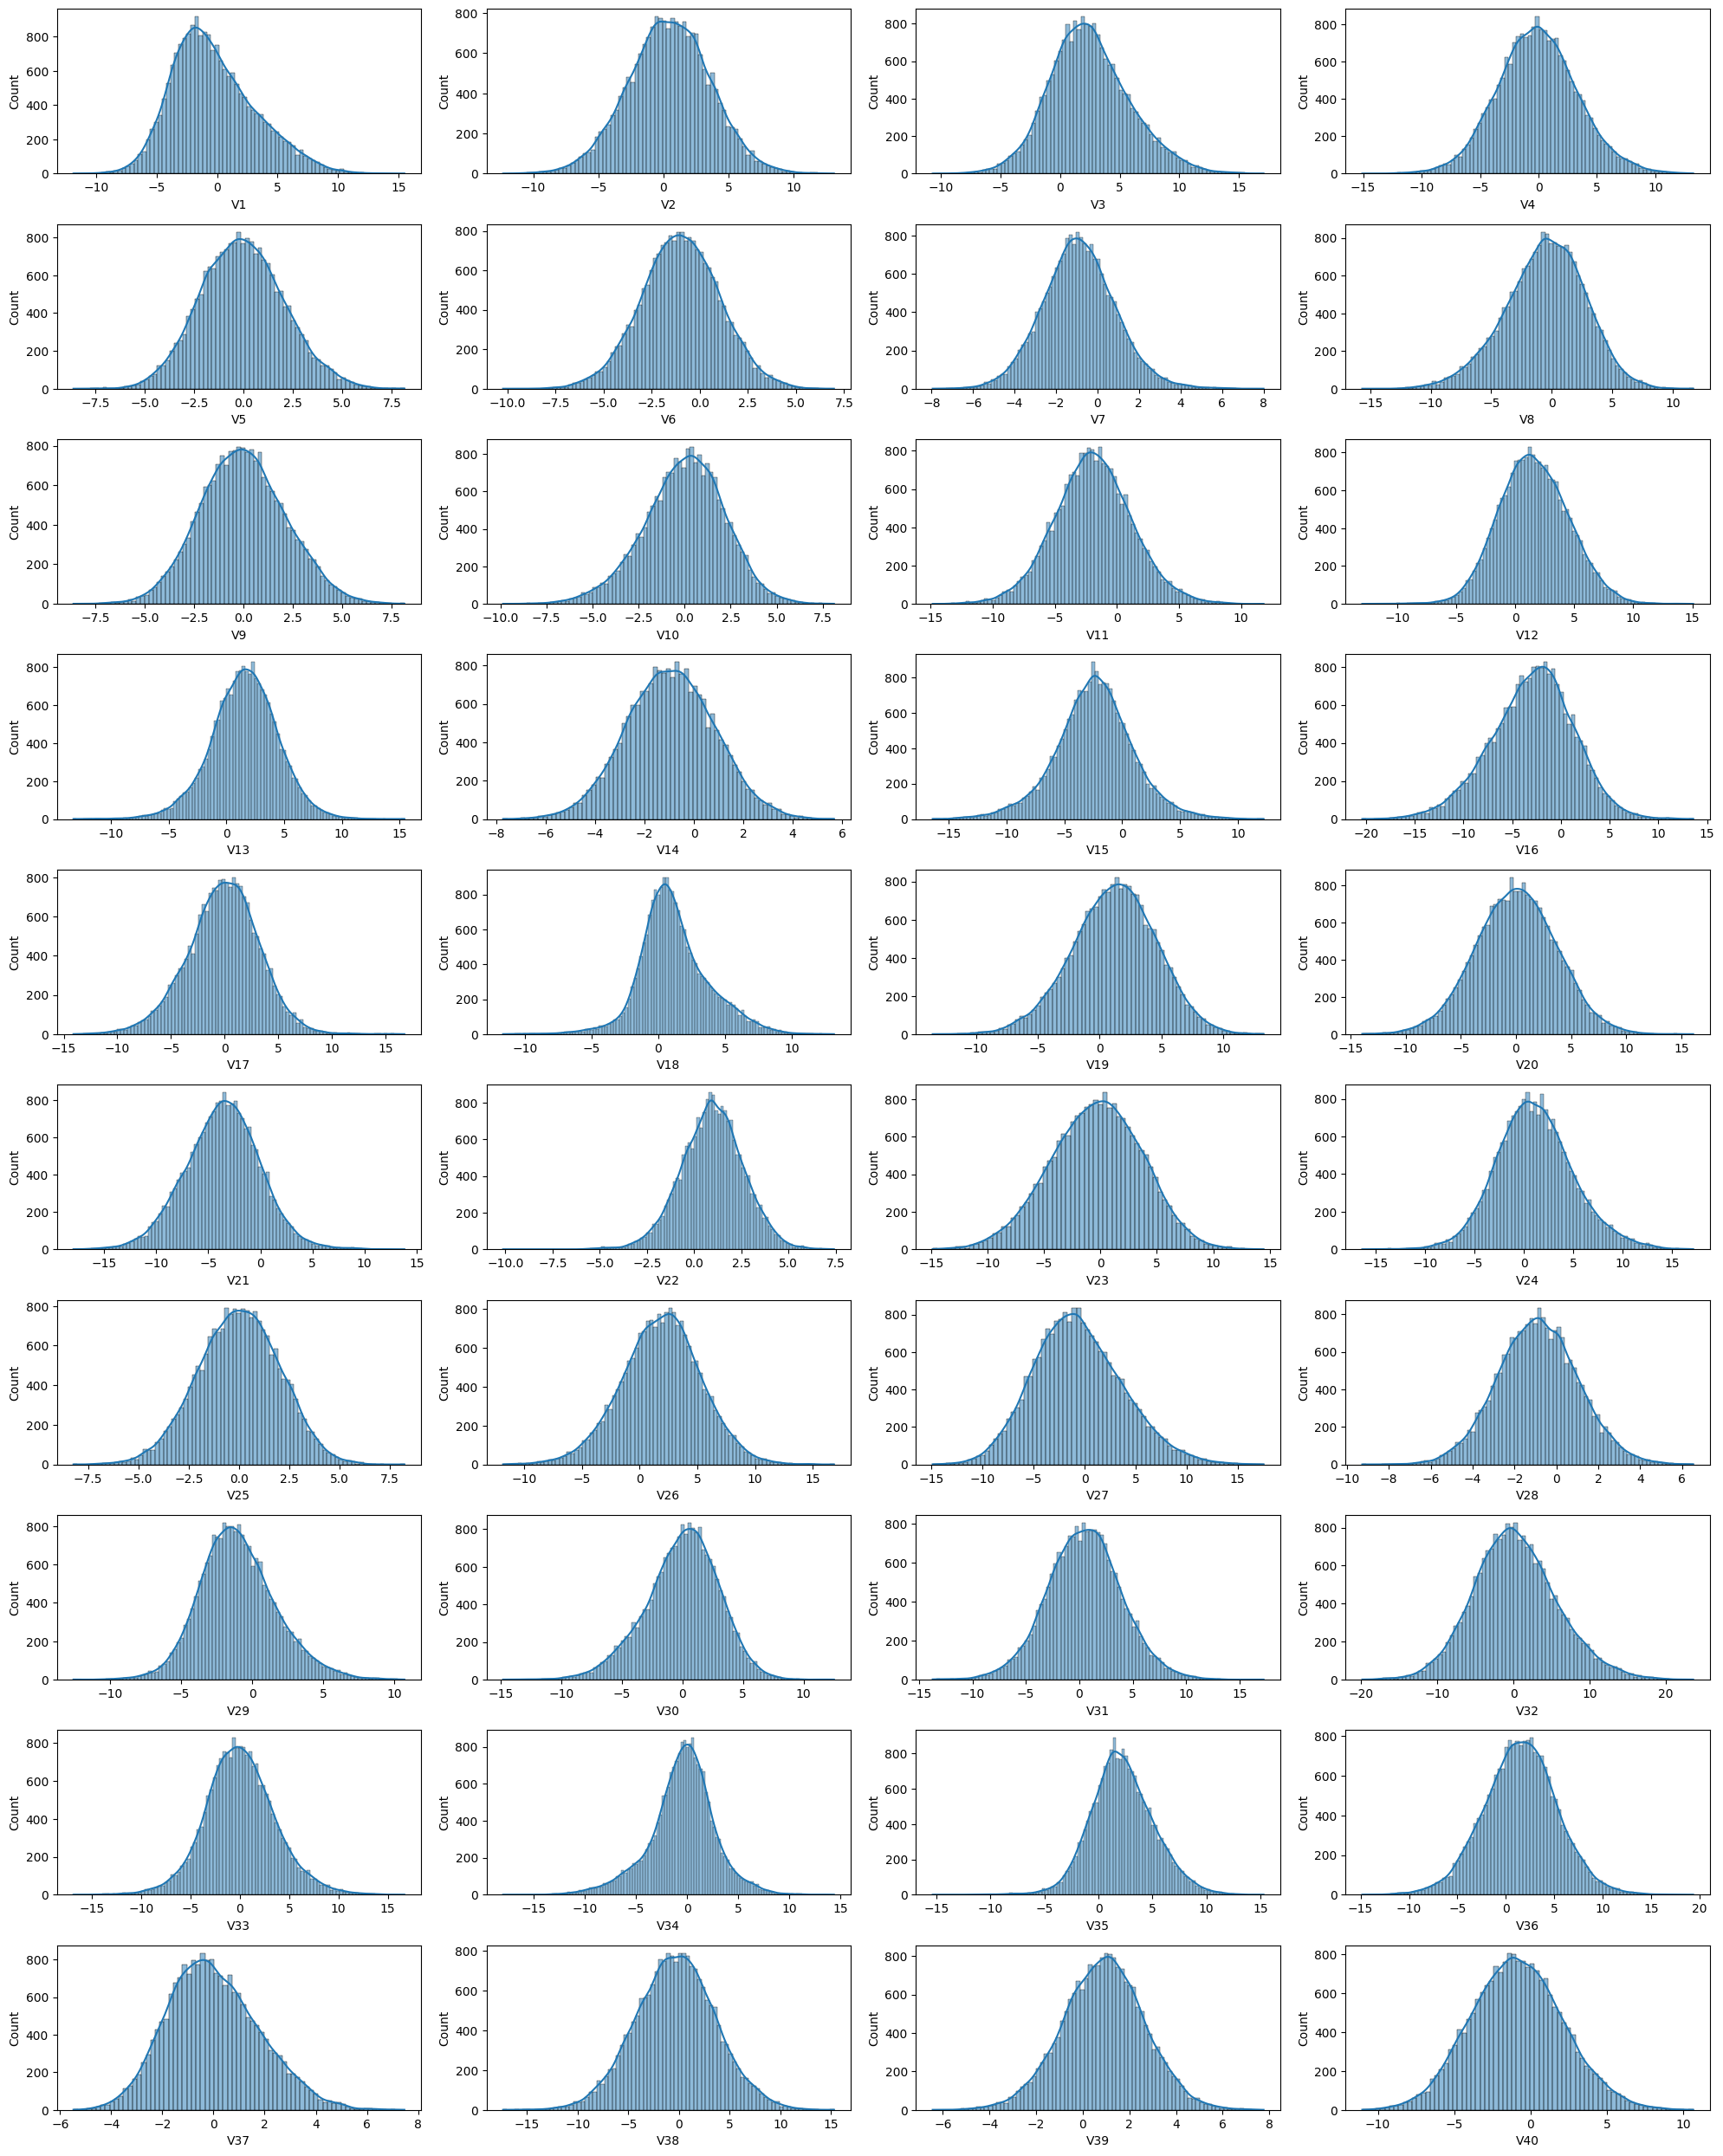

In [24]:
# Define the figure size
plt.figure(figsize=(20, 25))

# Plot the histogram for each numerical feature
for i, feature in enumerate(numerical_cols):
    plt.subplot(10, 4, i+1)    # assign a subplot in the main plot (3 per row)
    sns.histplot(data=train_df, x=feature, kde=True)    # plot the histogram

plt.tight_layout();   # Adds spacing between plots

These histogram plots confirms that the data has likely undergone significant pre-processing.

**Observations**:

1. Distribution Shape:
    - The Near-Normal Distributions: Almost every feature (V1-V40) exhibits a bell-shaped curve, characteristic of a Gaussian (Normal) distribution.
    * Symmetry: Most plots are highly symmetric. This suggests the data may have been transformed or generated from a process that naturally follows a normal distribution.
    
2. Central Tendency and Scaling
    - A quick glance at the x-axes shows that the majority of these distributions are centered around 0.
    - While they are centered at zero, the spread (variance) differs. For example, V16 and V32 have ranges extending beyond (+/-)20, while V5 and V39 are much tighter, mostly staying within (+/-)7.5.
    - This indicates that while the data might be centered, it hasn't been globally scaled to a unit variance
    
3. Skewness and Anomalies:

    - Features like V1, V18, and V22 appear slightly skewed compared to the near-perfect symmetry of V4 or V12.
    - The distributions are remarkably smooth with high counts (peaks around 800)
    - This suggests a well-populated dataset with 20,000 samples
    - These features are likely continuous measurements rather than masked categorical data.

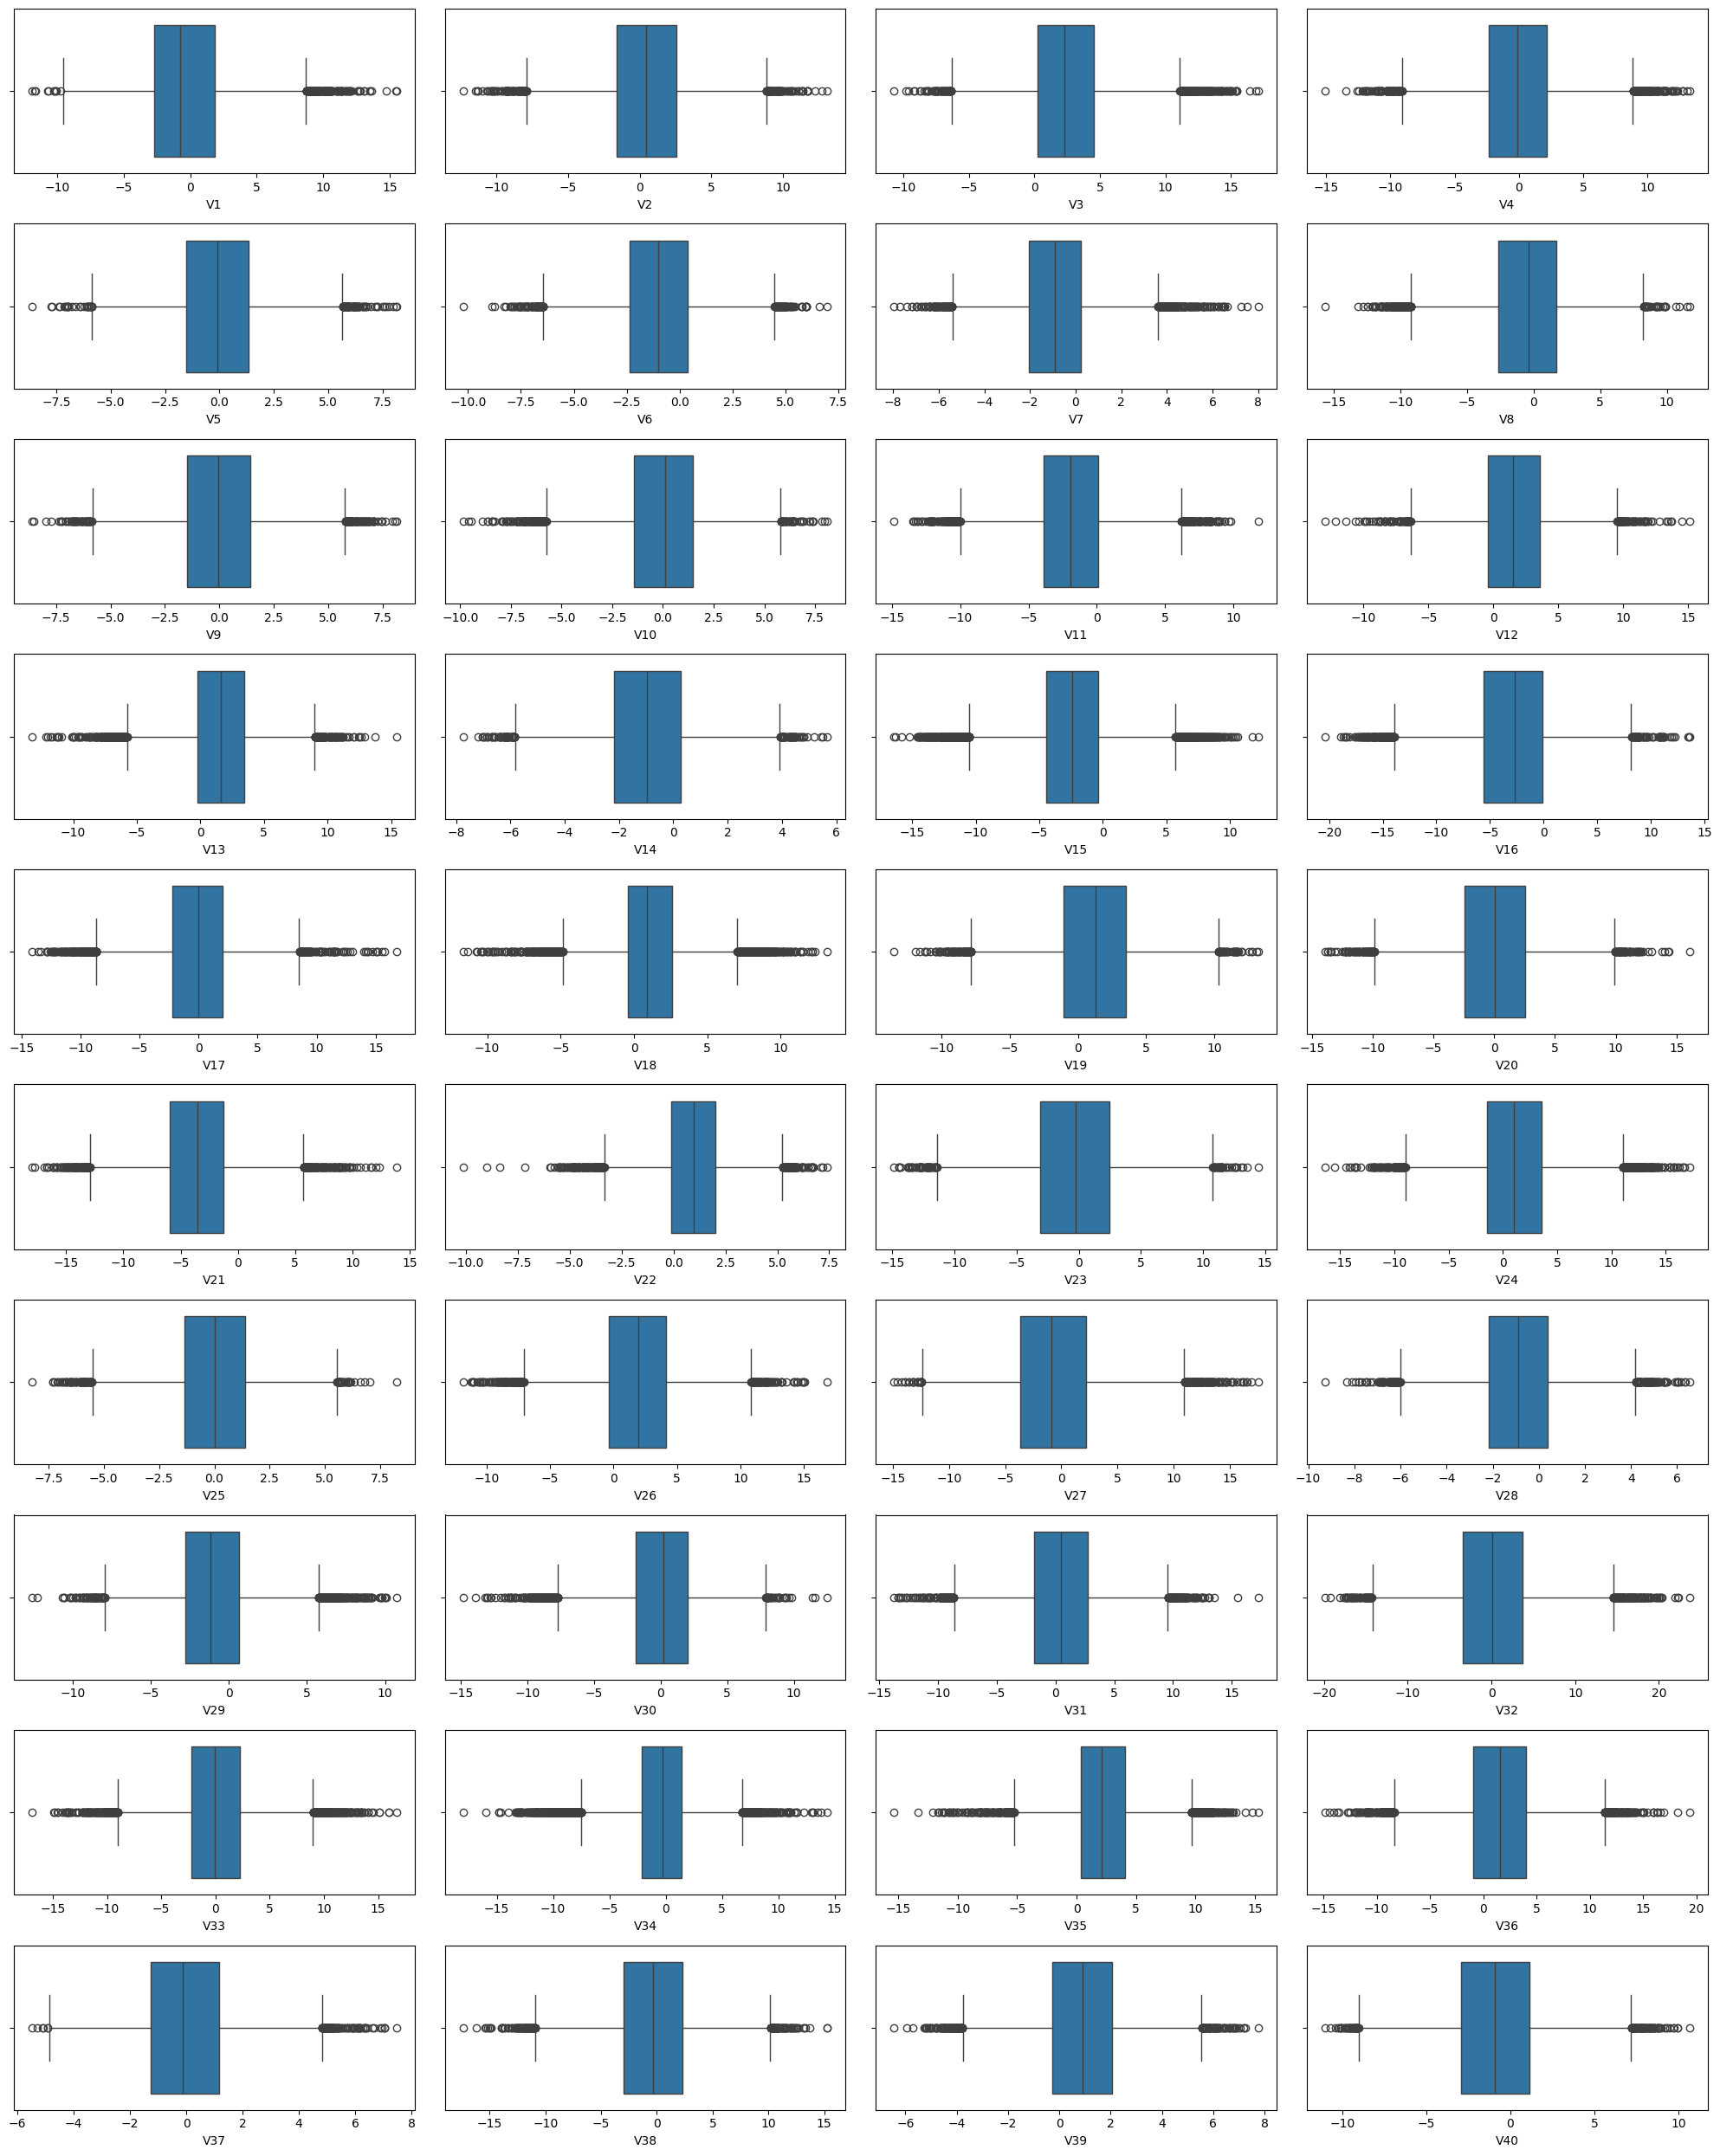

In [25]:
# Define the figure size
plt.figure(figsize=(20, 25))

# Plot the histogram for each numerical feature
for i, feature in enumerate(numerical_cols):
    plt.subplot(10, 4, i+1)    # assign a subplot in the main plot (1 per row)
    sns.boxplot(data=train_df, x=feature) # plot the boxplot

plt.tight_layout();   # Adds spacing between plots

**Observations:**

1. Presence of Outliers
    - The most striking feature across all 40 plots (V1-V40) is the high density of outliers
    - Most features show outliers on both the minimum and maximum ends. This is consistent with the distributions seen in the histograms.
    - Features like V13, V17, V26, and V35 show particularly thick clusters of outliers. In a dataset of 20,000 rows, seeing this many outliers suggests that while the data is "normal," it has heavy tails

2. Central Tendency and Spread
    - For the vast majority of variables, the median line (the vertical line inside the blue box) is centered within the box. This confirms that the data is not significantly skewed.
    - Most boxes are centered around 0 on the x-axis, reinforcing that the data has likely been centered.
    - The "Interquartile Range" (the width of the blue box) varies significantly across features. Couple of them show as: V16 (range of approx. -20 to 15) with V14 (range of approx. -8 to 6)

3. Specific Feature Nuances
    - V21 and V22 boxes are noticeably shifted away from zero compared to others, suggesting their mean/median values differ from the rest of the feature set.
    - V39 and V40 have very narrow boxes and whiskers compared to the early features (like V1-V4), indicating much lower variance.

Summary:

- Several features show **outliers** beyond the whiskers of the box plots (e.g., V1, V4, V8, V32).
- However, since the data is transformed/ciphered, these outliers may represent genuine extreme sensor readings rather than data errors.
- **We will not remove outliers** as they could represent critical failure scenarios that the model needs to learn from. Neural networks are relatively robust to outliers when proper scaling is applied.

##### Count plot for binary categorical variable

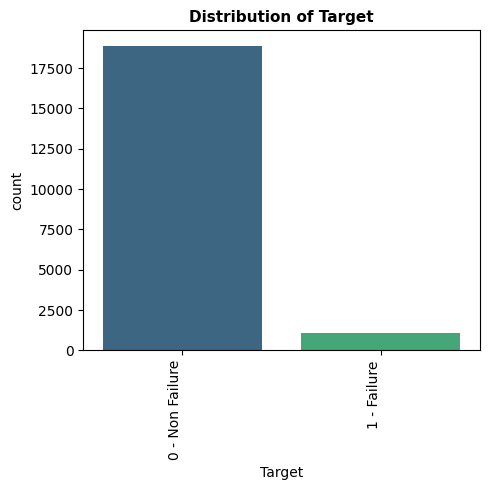

In [26]:
# checking the distribution of the Target

plt.figure(figsize=(5, 5)) # Adjust figure size

sns.countplot(train_df, x='Target', palette='viridis')    # plot the count plot
plt.title('Distribution of Target', fontsize=11, fontweight='bold')
plt.xlabel('Target')
plt.xticks(ticks=[0, 1], labels=['0 - Non Failure', '1 - Failure'], rotation = 90,  ha='right') # Set custom x-axis labels

plt.tight_layout();    # to add spacing between plots
plt.show()

**Observations:**

The "Distribution of Target" plot reveals a classic imbalanced classification problem:

- Majority Class (0 - Non Failure): This class accounts for nearly 19,000 of the 20,000 samples.

- Minority Class (1 - Failure): This class accounts for roughly 1,000 samples.

This class imbalance needs to be addressed while building / training the model.

#### Multi Variate Analysis

Let's try to understand the relation between numerical variables and binary categorical variable which we have identified earlier.



##### Correlation Map

1. Plot correlation map for all the numeric variables,
2. This helps in understanding the correlation with numeric variables.

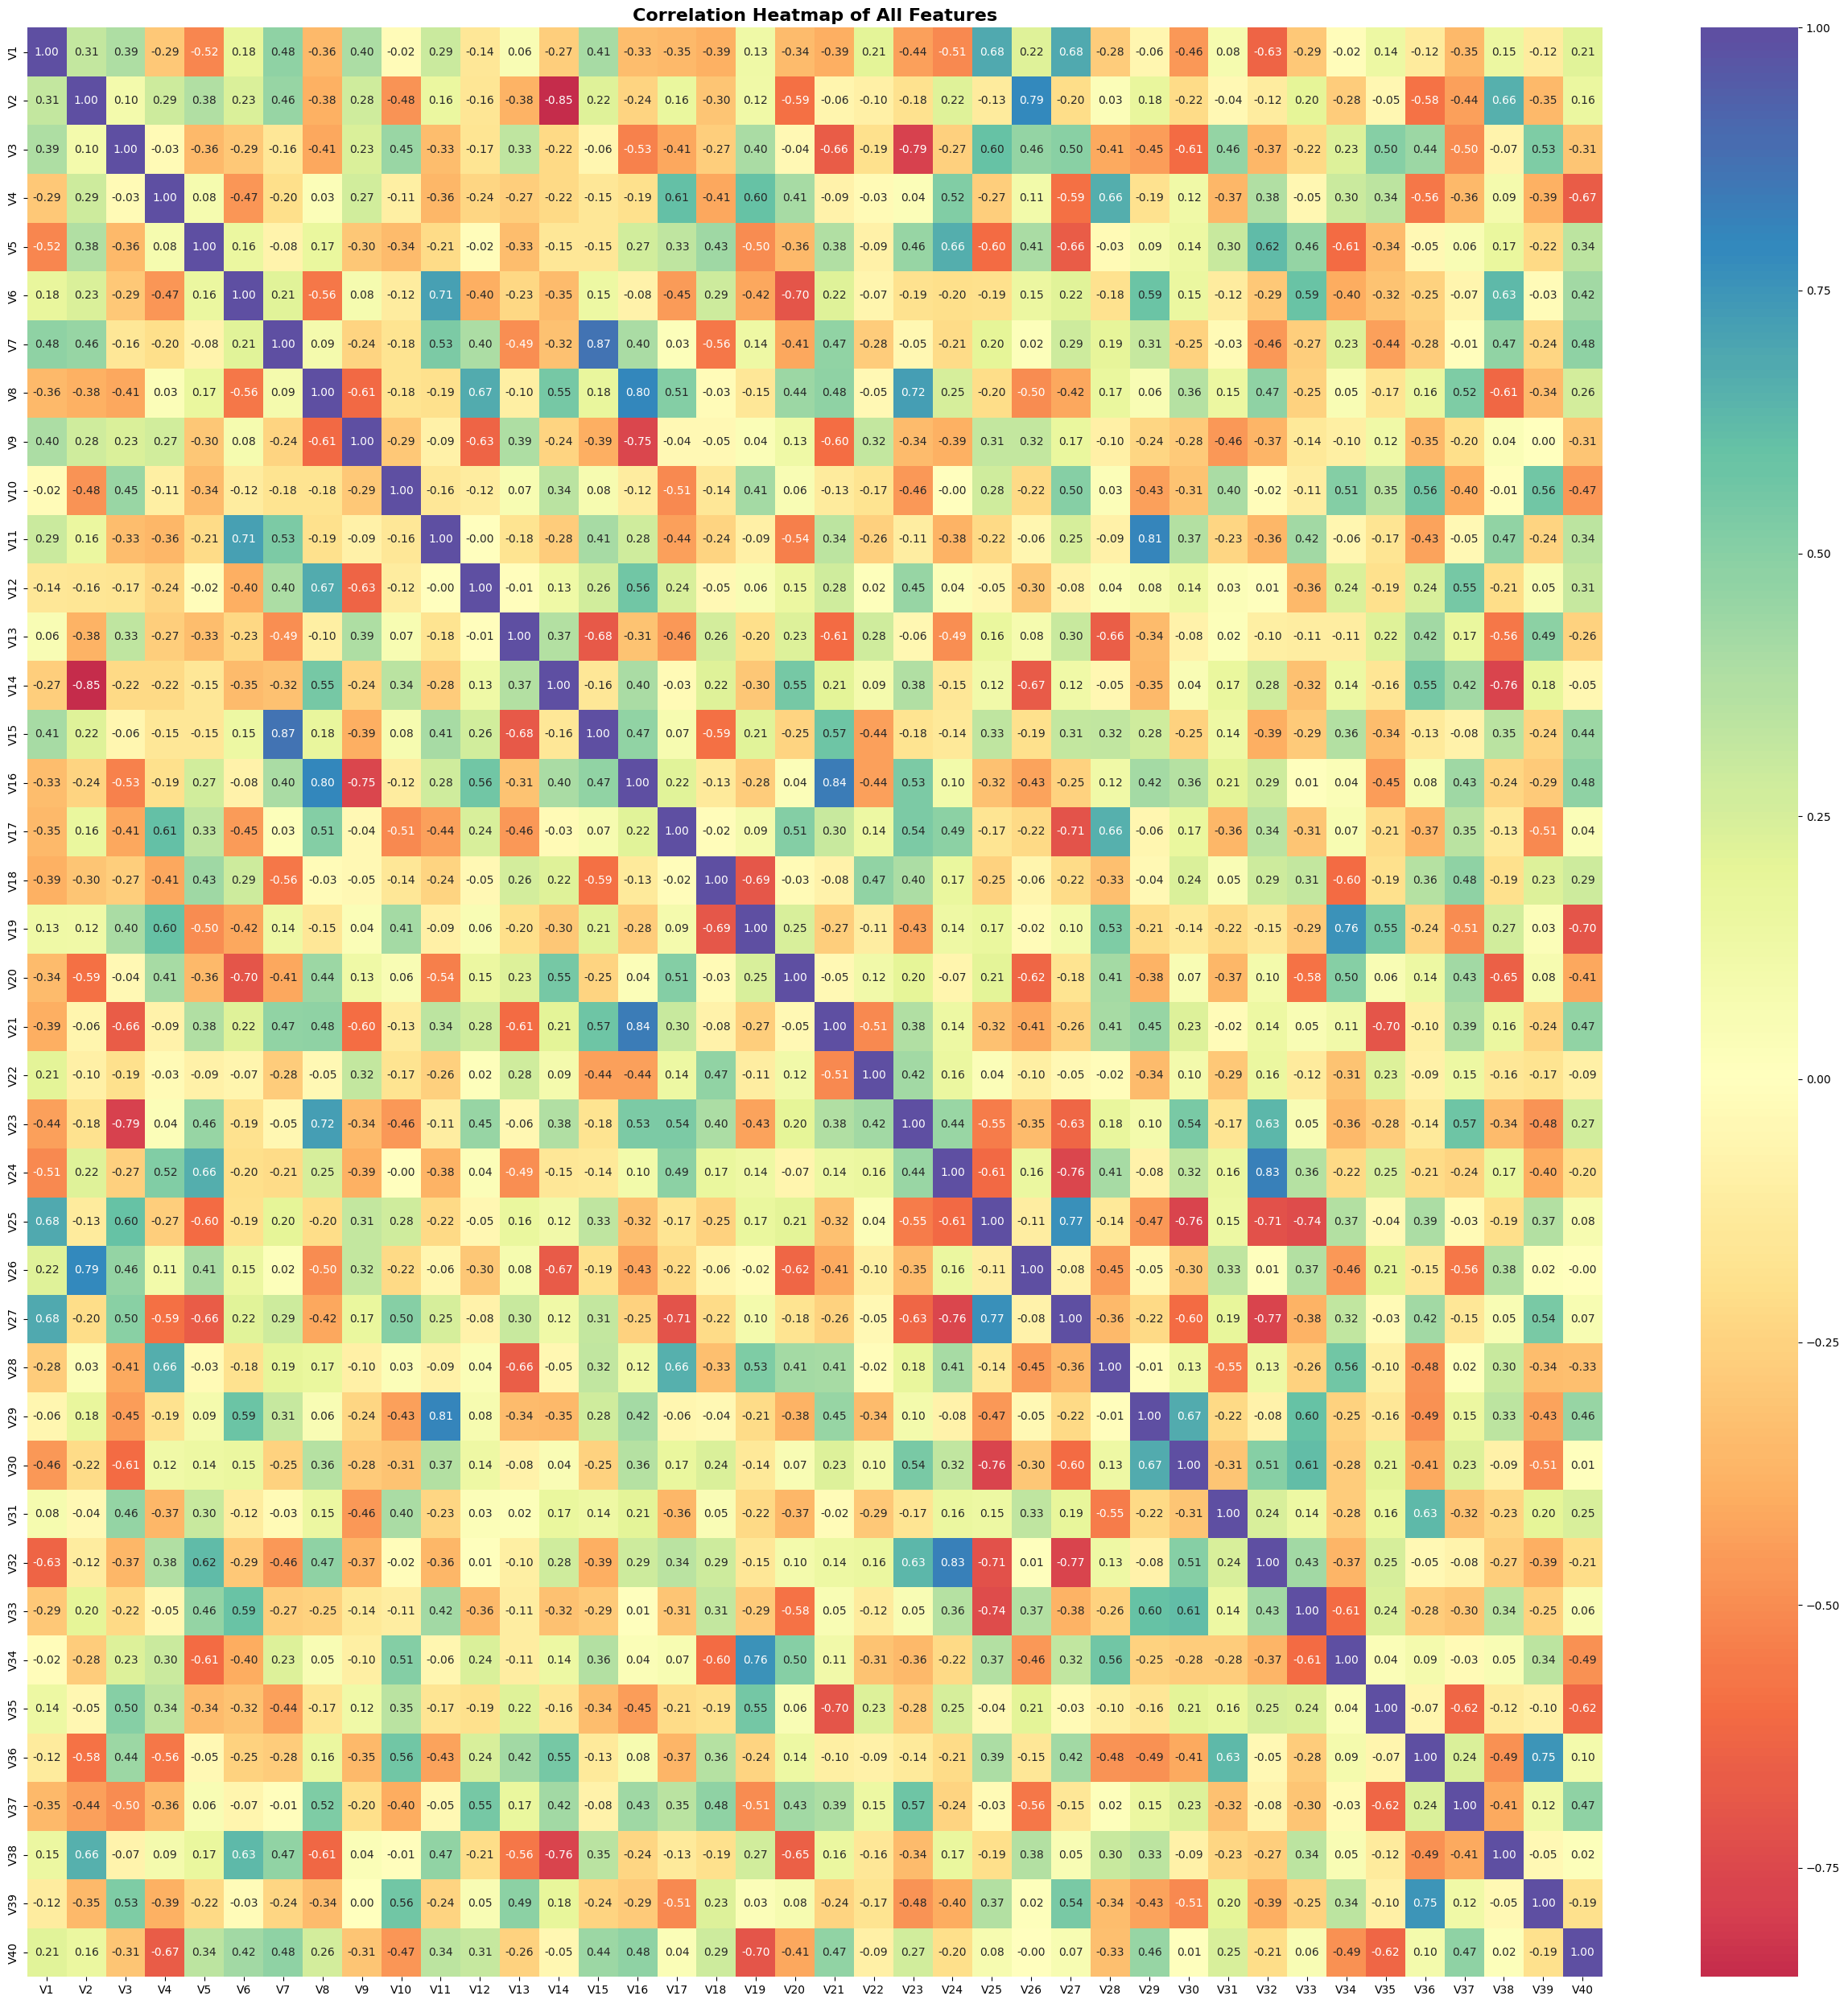

In [27]:
# Correlation heatmap
plt.figure(figsize=(25, 25))
corr_matrix = train_df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, cmap='Spectral', center=0,
            annot=True, fmt='.2f')
plt.title('Correlation Heatmap of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show();

**Observations:**

- This heatmap shows a mix of low, moderate, and high correlations.
- The dark blue line running diagonally from the top-left to the bottom-right represents the correlation of each variable with itself, which is the expected baseline.
- Several feature pairs exhibit strong linear relationships (indicated by darker blue for positive or darker red for negative correlations)
- **Positive Correlations:** Some pairs show high positive values, such as V1 and V12 (0.79), V7 and V15 (0.87), and V16 and V21 (0.84). These features move in the same direction.
- **Negative Correlations:** There are also significant inverse relationships, most notably V1 and V11 (-0.85) and V4 and V23 (-0.79). When one of these values increases, the other tends to decrease.
- Large sections of the heatmap are populated with light yellow or light green colors (values between -0.25 and 0.25), such as the relationships involving V31 or V39.

##### Target vs Numerical Values

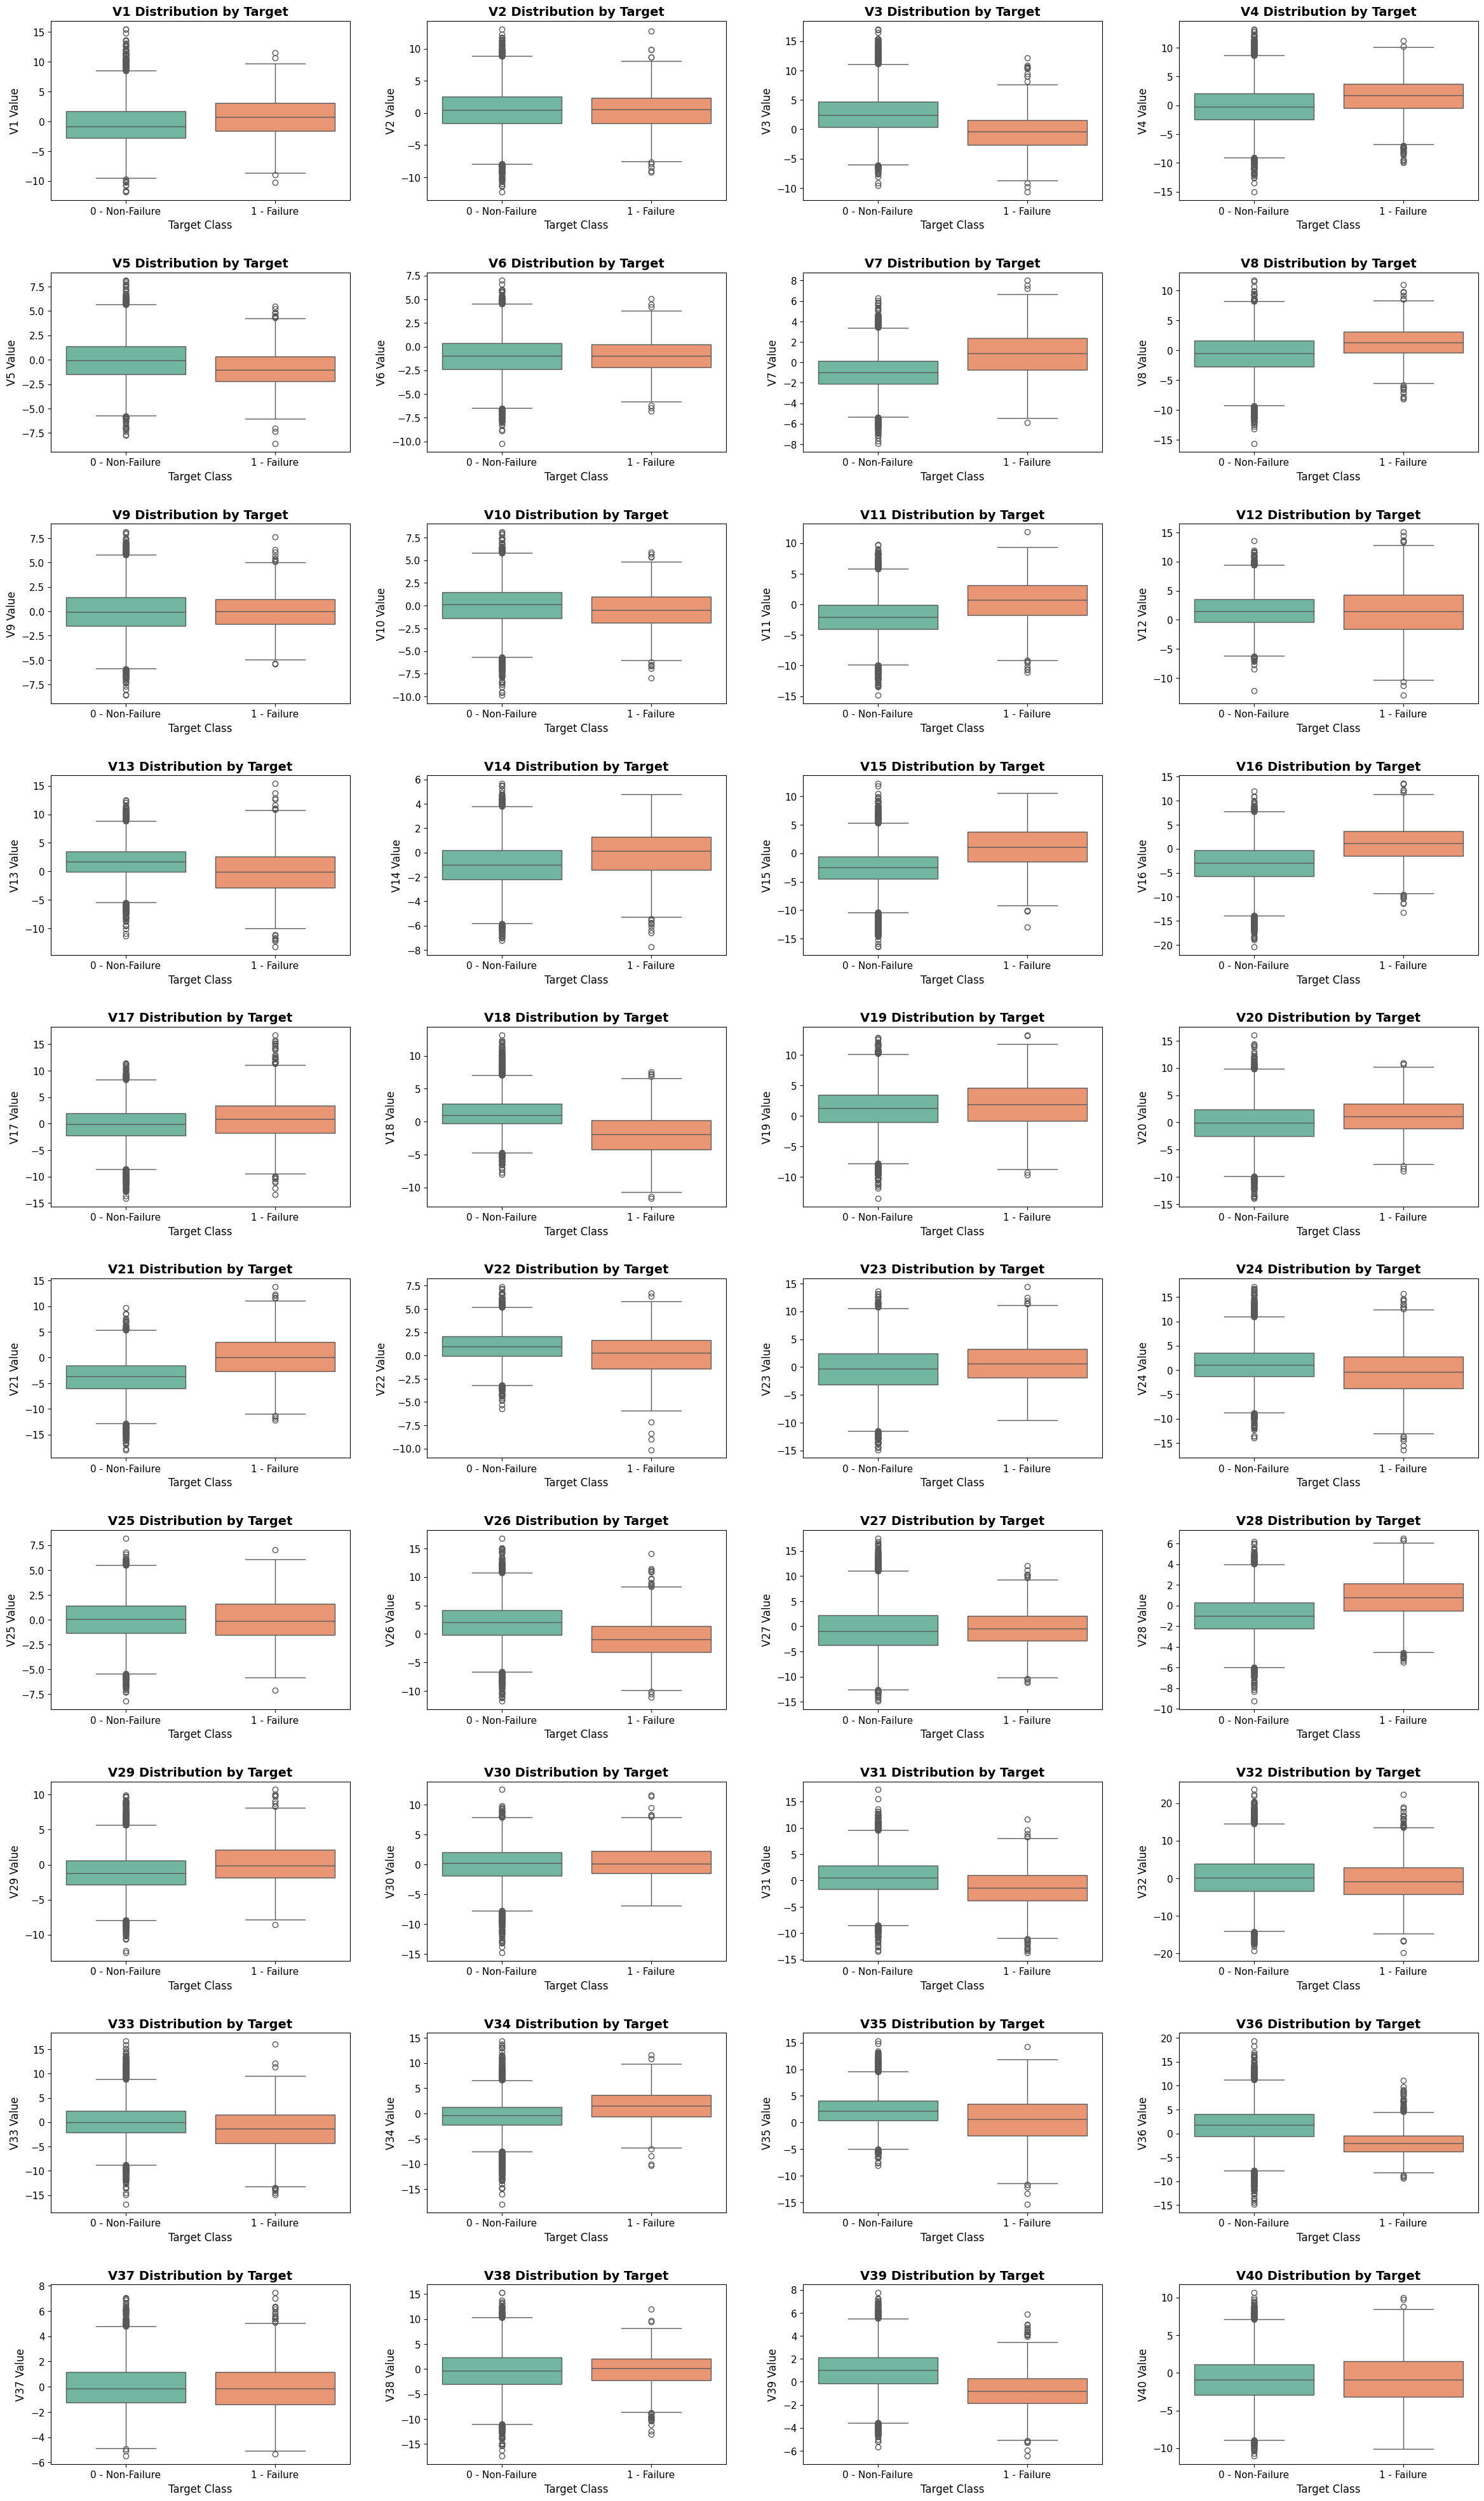

In [28]:
# 1. Create a temporary mapping for plotting so we don't ruin the original dataframe
plot_df = train_df.copy()
plot_df['Target_Label'] = plot_df['Target'].map({0: '0 - Non-Failure', 1: '1 - Failure'})

fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(24, 40))
axes = axes.ravel()

for idx, feature in enumerate(numerical_cols):
    # 2. Change x to 'Target_Label' and add hue='Target_Label' to force a legend
    sns.boxplot(
        data=plot_df,
        x='Target_Label',
        y=feature,
        hue='Target_Label', # This is what triggers the legend
        ax=axes[idx],
        palette='Set2'
    )

    axes[idx].set_title(f'{feature} Distribution by Target', fontsize=14, fontweight='bold')

    # 3. Clean up the labels
    axes[idx].set_xlabel('Target Class', fontsize=12)
    axes[idx].set_ylabel(f'{feature} Value', fontsize=12)
    axes[idx].tick_params(axis='both', which='major', labelsize=11)


plt.tight_layout(pad=3.0)
plt.show()

**Observations:**

- Features like V11, V14, V15, V16, V18, V21, V28, and V36 show a noticeable vertical shift in the median (the line inside the box) between the green (0) and orange (1) classes.

- While some features increase during a failure (like V11 or V15), others decrease significantly (like V18 or V36).

- Several features appear almost identical for both failure and non-failure cases.

- Features such as V1, V2, V5, V9, V10, V20, and V40 have almost perfectly aligned boxes and whiskers.

- In some cases, like V36, the "Failure" class (orange) has a much tighter Interquartile Range (the box height) than the "Non-Failure" class. This suggests that failures might occur within a very specific, narrow range for certain variables.

### Data Preprocessing (Contd)

#### Outlier Detection

Based on the above Box Plot for all the features (V1..V40),

- Several features show **outliers** beyond the whiskers of the box plots (e.g., V1, V4, V8, V32).
- However, since the data is transformed/ciphered, these outliers may represent genuine extreme sensor readings rather than data errors.
- **We will not remove outliers** as they could represent critical failure scenarios that the model needs to learn from. Neural networks are relatively robust to outliers when proper scaling is applied.

### Data Preparation for Modeling

- The analysis confirms that **Target** is the target variable for this classification problem.
- Binary categorical feature 'Target' already contains '0' or '1'. No encoding is needed here
- Missing values will be treated after the train-test split. We will fit the transformation on the training set only and then transform the validation/test sets. This standard practice prevents **data leakage** by ensuring the model is not exposed to information from the test set during training.

##### Split the train data

In [29]:
# Divide train data into X and y

# Drop the 'Target' column
X = train_df.drop(columns = ["Target"] , axis=1)

# Column named 'Target' becomes y
y = train_df["Target"]

In [30]:
# Split data into training and validation set with 20% of the data allocated to validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [31]:
# Check the shape of X_train and y_train
print(X_train.shape)
print(y_train.shape)

# Check the shape of X_val and y_val
print(X_val.shape)
print(y_val.shape)

(16000, 40)
(16000,)
(4000, 40)
(4000,)


**Observations:**

- Target feature is not removed from input features
- The train data set now contains 16000 rows and 40 columns
- The validation data set contains remaining 4000 rows and 40 columns

In [32]:
# Divide test data into X_test and y_test

# Drop the 'Target' column for X
X_test = test_df.drop(columns = ['Target'] , axis= 1)

# Retain only 'Target' column for y
y_test = test_df["Target"]

In [33]:
# Check the shape of X_test and y_test
print(X_test.shape)
print(y_test.shape)

(5000, 40)
(5000,)


**Observations:**

The test data set contains 5000 rows and 40 columns

In [34]:
# Helper function to format the string
def format_distribution(y_data):
    counts = pd.Series(y_data).value_counts().sort_index()
    percents = pd.Series(y_data).value_counts(normalize=True).sort_index() * 100
    # Creates a string like: "0: 5000 (33.0%), 1: 10000 (67.0%)"
    return ", ".join([f"{cls}: {count} ({percents[cls]:.1f}%)" for cls, count in counts.items()])


print("Data Split Summary:")
print(f"{'='*50}")
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(y)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(y)*100:.1f}%)")

print(f"\nClass distribution:")
print(f"Training:   {format_distribution(y_train)}")
print(f"Validation: {format_distribution(y_val)}")
print(f"Test:       {format_distribution(y_test)}")

Data Split Summary:
Training set:   16000 samples (80.0%)
Validation set: 4000 samples (20.0%)
Test set:       5000 samples (25.0%)

Class distribution:
Training:   0: 15112 (94.5%), 1: 888 (5.5%)
Validation: 0: 3778 (94.5%), 1: 222 (5.5%)
Test:       0: 4718 (94.4%), 1: 282 (5.6%)


Observations:

1. The most critical observation is that the dataset is highly imbalanced.

2. It can be observed that the proportion is divided perfectly for training, validation sets and test set.

3. The target variable Target shows imbalance, with 94.5% Non-Failure (Majority) and 5.5% Failure cases (Minority)

4. Given the imbalance and the cost of errors, we will prioritize the Recall over Accuracy

    - **False Positives (Predicts Failure '1', Actual is Normal '0'):**
    
        - The model triggers a false alarm. ReneWind sends a technician to inspect the wind turbine, but they find nothing wrong.
        - Cost: The cost of a routine inspection and minor labor hours. (Relatively Low Cost).

    - **False Negatives (Predicts Normal '0', Actual is Failure '1'):**
        - The model fails to catch an impending breakdown. The generator runs until it completely destroys itself.
        - Cost: Catastrophic generator replacement, massive physical damage to the turbine, and prolonged operational downtime where no electricity is generated. (Massive Cost).

Because a False Negative is exponentially more expensive and dangerous than a False Positive, our primary goal is to minimize False Negatives.

However, let's also make sure to monitor Precision(balanced F1 score) ensuring the model is optimised well.

5. Balancing the class proportion while predicting the model also plays a crucial role

##### Missing Values Treatment

Imputation:

In [35]:
#We have observed around 18 samples in training data has missing values for V1 and V2 features. Let's treat them.

imputer = SimpleImputer(strategy="median") #Strategy used is Median for imputing

# Fit and transform the train data - calculates the median from the training data and imputes missing values
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data using the median calculated from the training data
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

# Transform the test data using the median calculated from the training data
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

# Verify that no data set has any values missing
print("Missing values in X_train : ", X_train.isnull().sum())
print("-" * 30)
print("Missing values in X_val : ", X_val.isnull().sum())
print("-" * 30)
print("Missing values in X_test : ", X_test.isnull().sum())

Missing values in X_train :  V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
Missing values in X_val :  V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
Missing values in X_test :  V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0


**Observations:**

- We used the median strategy rather than the mean to impute the missing values in features V1 and V2 since this dataset consists of continuous sensor readings, sensor data is highly prone to sudden spikes, noise, or outliers.

- The mean is highly sensitive to outliers and could skew the imputed values, whereas the median provides a robust, central value that represents the typical sensor reading much more accurately.

- The SimpleImputer was strictly fitted (fit_transform) only on the training data (X_train).

- The validation (X_val) and test (X_test) sets were solely transformed (transform) using the median values learned from the training set.

  **Data Leakage Problem:**
    - If we had calculated the median using the entire dataset before splitting, information from the validation and test sets would have "leaked" into the training process.
    - By isolating the imputation parameters to the training set, we ensure our model's evaluation remains completely unbiased and simulates real-world deployment where future data is completely unseen.

- Because 18 samples make up a tiny fraction of a percent of the 16,000 total training samples, filling them with the median will not artificially distort the overall variance or distribution of features V1 and V2.

- The final verification step confirms 0 missing values across all three datasets.


Scaling:

In [36]:
# Standardizing all the columns
# This is to ensure that all features contribute equally, training becomes more stable, and the network can learn faster

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
# This calculates the mean and standard deviation from the training data and applies the transformation
X_train = scaler.fit_transform(X_train)

# Transform the validation data using the scaler fitted on the training data
# This ensures that the validation data is scaled using the same parameters as the training data, preventing data leakage
X_val = scaler.transform(X_val)

# Transform the test data using the scaler fitted on the training data
# This ensures consistency in scaling across all datasets
X_test = scaler.transform(X_test)

print("type(X_train) : ", type(X_train))
print("type(X_val) : ", type(X_val))
print("type(X_test) : ", type(X_test))

print("X_train shape : ", X_train.shape)
print("X_val shape : ", X_val.shape)
print("X_test shape : ", X_test.shape)

# Convert target variables to NumPy arrays for compatibility with neural network libraries
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

type(X_train) :  <class 'numpy.ndarray'>
type(X_val) :  <class 'numpy.ndarray'>
type(X_test) :  <class 'numpy.ndarray'>
X_train shape :  (16000, 40)
X_val shape :  (4000, 40)
X_test shape :  (5000, 40)


**Observations:**

- We apply Standard Scaling to ensure all 40 ciphered sensor features share a mean of 0 and a standard deviation of 1, preventing any single feature from mathematically dominating the model simply due to a wider natural variance.
- This equalized scale creates a uniform loss landscape, allowing the neural network's optimizer to converge faster and more stably.
- The **StandardScaler** was fitted (fit_transform) exclusively on the training set (X_train) to learn the mean and standard deviation.
- The validation and test sets were strictly transformed (transform) using these pre-learned parameters.
- This ensures that the model is entirely blind to the statistical distribution of the unseen data, preventing **data leakage**.

# Model Building

### Model Evaluation Criteria

Model can make wrong predictions as:

| Prediction Outcome | Business Impact | Cost Level |
|---|---|---|
| **False Negative (FN)** | Missed failure → Replacement | **Highest** |
| **False Positive (FP)** | False alarm → Inspection | Lowest |

**Primary Metric: Recall (Sensitivity) for Class 1**

- In predictive maintenance for wind turbine generators, we must evaluate the model based on the cost of making a mistake. Let's look at the two types of errors the model can make:

    - False Positive (Predicts Failure '1', Actual is Normal '0'): 
      - Business Impact: The model triggers a false alarm. ReneWind sends a technician to inspect the wind turbine, but they find nothing wrong.

      - Cost: The cost of a routine inspection and minor labor hours. (Relatively Low Cost).

    - False Negative (Predicts Normal '0', Actual is Failure '1'):

        - Business Impact: The model fails to catch an impending breakdown. The generator runs until it completely destroys itself.

        - Cost: Catastrophic generator replacement, massive physical damage to the turbine, and prolonged operational downtime where no electricity is generated. (Massive Cost).



**Rationale:**
- **Missing a failure (FN) is the most costly outcome** - it leads to generator replacement, which is far more expensive than repair.
- **Recall = TP / (TP + FN)** - maximizing recall minimizes missed failures.
- While high recall may lead to some false positives (unnecessary inspections), the cost of inspection is the **lowest** among all outcomes.
- We will also monitor **F1-score** as a secondary metric to ensure a reasonable balance between recall and precision.
- **Accuracy is NOT a suitable primary metric** here because the dataset is highly imbalanced - a model predicting all "no failure" would achieve ~94.5% accuracy but would not be helpful

As we have are dealing with an imbalance in class distribution, we will be using class weights to allow the model to give proportionally more importance to the minority class.

In [37]:
# Since the class is imabalnced in the data, we'll use class weights in all the models
# Calculate class weights for imbalanced dataset. This gives higher weight to the minority class.
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int))

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

Define common-reusable functions

In [38]:
#Plot loss/accuracy/recall
def plot(history, name):
    """
    Function to plot loss/accuracy/recall

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy or Recall
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy/recall or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy/recall or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [39]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='macro')  # to compute Recall
    precision = precision_score(target, pred, average='macro')  # to compute Precision
    f1 = f1_score(target, pred, average='macro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},
        index=[0],
    )

    return df_perf

NOTE:

- Including average='macro' helps to calculate the performance metric (e.g., Recall, F1, precision) for each class independently and then takes the unweighted mean. 
- It treats all classes equally, regardless of their support (number of samples), making it ideal for highlighting performance on minority classes in imbalanced datasets.

In [40]:
def confusion_matrix_sklearn(model, predictors, target, ax=None, threshold=0.5):
    """
    To plot the confusion_matrix with percentages on a specific axis.

    model: classifier
    predictors: independent variables
    target: dependent variable
    ax: matplotlib axes object (optional)
    threshold: threshold for classifying the observation as class 1
    """
    # Convert probabilities to binary predictions using the threshold
    y_pred_proba = model.predict(predictors)
    y_pred = (y_pred_proba > threshold).astype(int)

    cm = confusion_matrix(target, y_pred)

    # Create the labels with counts and percentages
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    # If no axis is passed, create a new figure (for standalone use)
    if ax is None:
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=labels, fmt="")
        plt.ylabel("True label")
        plt.xlabel("Predicted label")
        plt.show()
    else:
        # Plot on the passed axis
        sns.heatmap(cm, annot=labels, fmt="",  ax=ax, cbar=False)
        ax.set_ylabel("True label")
        ax.set_xlabel("Predicted label")

### Model 0 - No Class Weights

- Let's start with a neural network consisting of
  - one hidden layer with 7 neurons
  - activation function of ReLU.
  - SGD as the optimizer

In [41]:
# Clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [42]:
# Initializing the neural network with 7 neurons
model = Sequential()
model.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(1,activation="sigmoid"))

In [43]:
# Summary of the model configuration
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used

# Compile with:
# 1. SGD Optimiser
# 2. Recall Metrics
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])


**Observations:**
- Model 0 is a simple feedforward neural network with **1 hidden layer** (7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **SGD optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 295

In [45]:
# Fit the model with batch size as 32 and Epochs as 25

start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=32, epochs=25) # No class weights are added here
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.1358 - loss: 0.4226 - val_Recall: 0.0405 - val_loss: 0.1784
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.0572 - loss: 0.1644 - val_Recall: 0.1892 - val_loss: 0.1437
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.2217 - loss: 0.1343 - val_Recall: 0.3694 - val_loss: 0.1271
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.3556 - loss: 0.1183 - val_Recall: 0.4550 - val_loss: 0.1174
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.4399 - loss: 0.1085 - val_Recall: 0.5180 - val_loss: 0.1112
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.4755 - loss: 0.1023 - val_Recall: 0.5405 - val_loss: 0.1072
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5034 - loss: 0.0981 - val_Recall: 0.5495 - val_loss: 0.1043
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5283 - loss: 0.0951 - val_Recall: 0.5631 - val_loss: 0.1021
Epoch 9/

In [46]:
print("Time taken in seconds ",end-start)

Time taken in seconds  22.569127321243286


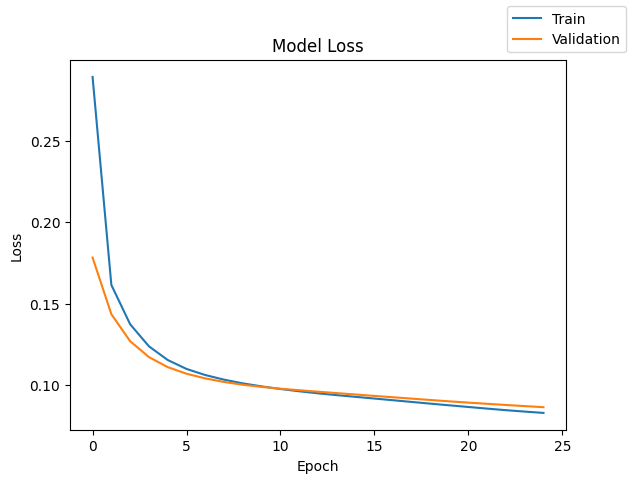

In [47]:
# Plot Model Loss

plot(history,'loss')

**Note:** Shows no much gap between training and validation loss

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step


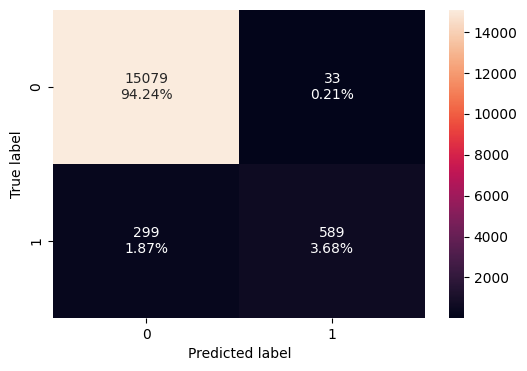


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


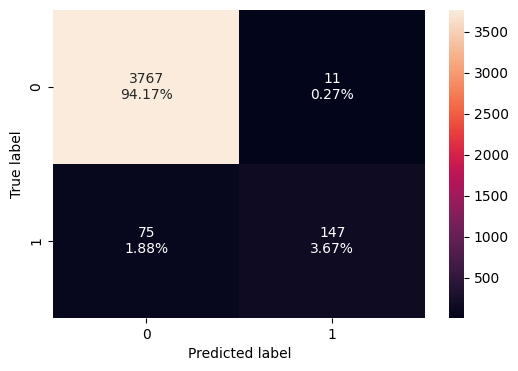

In [48]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 0.21% False Positives, 1.87% False negatives
* Validation
  - Confusion matrix shows around 0.27% False Positives, 1.88% False negatives


In [49]:
# Train Performance Metrics

model_0_train_perf = model_performance_classification(model, X_train, y_train)
model_0_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step


,Accuracy,Recall,Precision,F1 Score
0,0.97925,0.830552,0.963751,0.884622


In [50]:
# Validation Performance Metrics

model_0_valid_perf = model_performance_classification(model, X_val, y_val)
model_0_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9785,0.829625,0.955429,0.881199


**Observations:**

These performance metrics for "Model 0" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

1. Accuracy: Stays consistent at approximately 97%.
2. F1 Score: Remains stable, moving only slightly from 0.884 (Train) to 0.881 (Validation).
3. Precision (0.955 - Validation): When the model flags a potential failure, it is correct about 95.5% of the time. This minimizes costly false alarms.
4. Recall (0.82 - Validation): The model captures approximately 82.9% of all actual failure cases. While good mark, this means about 17.1% of failures are still going undetected.

Given that our primary objective is to maximize **Recall** to ensure all potential failures are captured, the current performance suggests that the model's loss function is likely prioritizing the majority class. This needs weights to be balanced

### Model 1 - Include Class Weights

- Include Class Weights to handle the imbalanced data
  - one hidden layer with 7 neurons
  - activation function of ReLU.
  - SGD as the optimizer
  - class weights

In [51]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [52]:
#Initializing the neural network
model_1 = Sequential()
model_1.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model_1.add(Dense(1,activation="sigmoid"))

In [53]:
# Summary of the model configuration

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used

# Compile with:
# 1. SGD Optimiser
# 2. Recall Metrics
model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

**Observations:**
- Model 1 is a simple feedforward neural network with **1 hidden layer** (7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **SGD optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 295

In [55]:
# Fit the model with batch size as 32, Epochs as 25 and include class_weight

start = time.time()
history = model_1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=32, epochs=25, class_weight=cw_dict) # Class weight is assigned here
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8738 - loss: 0.9185 - val_Recall: 0.8739 - val_loss: 0.4082
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.8740 - loss: 0.6401 - val_Recall: 0.8829 - val_loss: 0.3537
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.8736 - loss: 0.5927 - val_Recall: 0.8784 - val_loss: 0.3259
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8747 - loss: 0.5649 - val_Recall: 0.8784 - val_loss: 0.3102
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8769 - loss: 0.5461 - val_Recall: 0.8829 - val_loss: 0.2934
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8804 - loss: 0.5313 - val_Recall: 0.8829 - val_loss: 0.2796
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8783 - loss: 0.5157 - val_Recall: 0.8784 - val_loss: 0.2658
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8872 - loss: 0.4947 - val_Recall: 0.8784 - val_loss: 0.2518
Epoch 9/

In [56]:
print("Time taken in seconds ",end-start)

Time taken in seconds  21.695016145706177


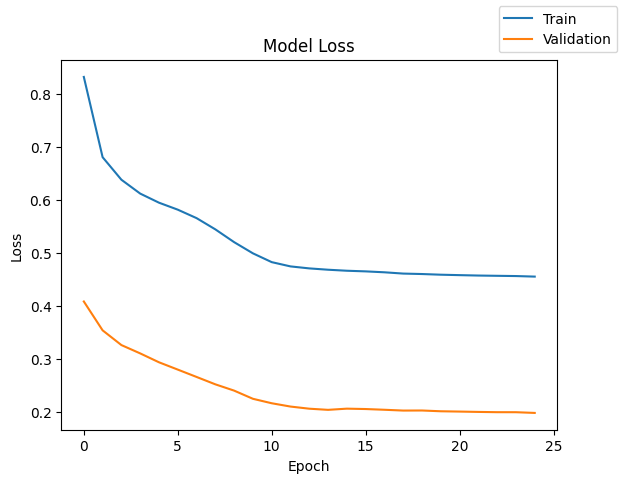

In [57]:
# Plot Model Loss

plot(history,'loss')

**Note:** There's significant gap between training and validation loss

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step


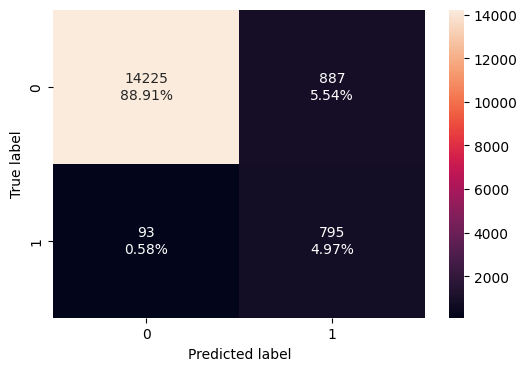


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step


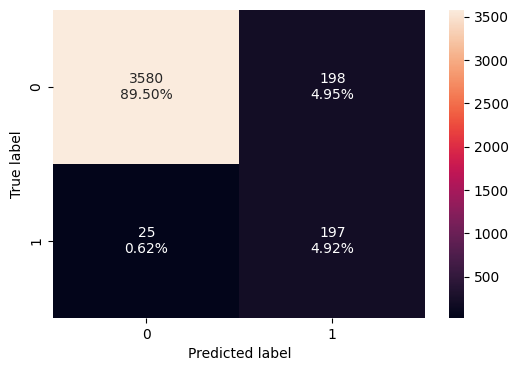

In [58]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_1, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_1, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 5.54% False Positives, 0.58% False negatives
* Validation
  - Confusion matrix shows around 4.95% False Positives, 0.62% False negatives


In [59]:
# Train Performance Metrics

model_1_train_perf = model_performance_classification(model_1, X_train, y_train)
model_1_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step


,Accuracy,Recall,Precision,F1 Score
0,0.93875,0.918288,0.733078,0.792689


In [60]:
# Validation Performance Metrics

model_1_valid_perf = model_performance_classification(model_1, X_val, y_val)
model_1_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step


,Accuracy,Recall,Precision,F1 Score
0,0.94425,0.917489,0.7459,0.804185


**Observations:**

*Model Performance:*

These performance metrics for "Model 1" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Model 1 achieved a Validation Recall of 0.917, a substantial increase from Model 0.
- Validation Precision fell to 0.745 (Model 1)
- For Model 1, the Validation Recall (0.917) is almost identical to the Training Recall (0.918). This indicates that model generalised well, and improvement in recall value shows the impact of class weights
- Accuracy is maintained at 93% for training and at 94% for validation metrics

However, this model needs improvement on Recall and Precision

# Model Performance Improvement

Let's try to improve the performance of the models to maximise Recall (our high priority metric), and also making sure to maintain acceptable precision metric

### Model 2 - Increase Epoch - 50

- Include Class Weights to balance the imbalanced data
  - one hidden layer with 7 neurons
  - activation function of ReLU.
  - SGD as the optimizer
  - class weights
  - Increase Epochs to 50

In [61]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [62]:
#Initializing the neural network

model_2 = Sequential()
model_2.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model_2.add(Dense(1,activation="sigmoid"))

In [63]:
# Summary of the model configuration

model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used

# Compile with:
# 1. SGD Optimiser
# 2. Recall Metrics
model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 2 is a simple feedforward neural network with **1 hidden layer** (7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **SGD optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 295

In [65]:
# Fit the model with batch size as 32, Epochs as 50 and include class_weight

start = time.time()
history = model_2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=32, epochs=50,class_weight=cw_dict)
end=time.time()

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8473 - loss: 1.0500 - val_Recall: 0.8964 - val_loss: 0.3948
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8828 - loss: 0.6161 - val_Recall: 0.8964 - val_loss: 0.3254
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8940 - loss: 0.5502 - val_Recall: 0.9054 - val_loss: 0.3029
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8982 - loss: 0.5225 - val_Recall: 0.9054 - val_loss: 0.2896
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9009 - loss: 0.5078 - val_Recall: 0.9009 - val_loss: 0.2797
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8961 - loss: 0.4972 - val_Recall: 0.8919 - val_loss: 0.2737
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8863 - loss: 0.4898 - val_Recall: 0.8919 - val_loss: 0.2692
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8880 - loss: 0.4834 - val_Recall: 0.8919 - val_loss: 0.2655
Epoch 9/

In [66]:
print("Time taken in seconds ",end-start)

Time taken in seconds  44.49126648902893


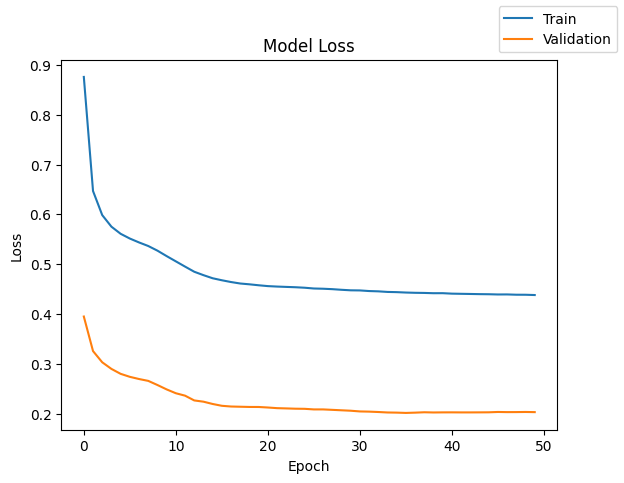

In [67]:
#Plot Model loss

plot(history,'loss')

**Note:** This shows significant gap between validation and training loss

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step


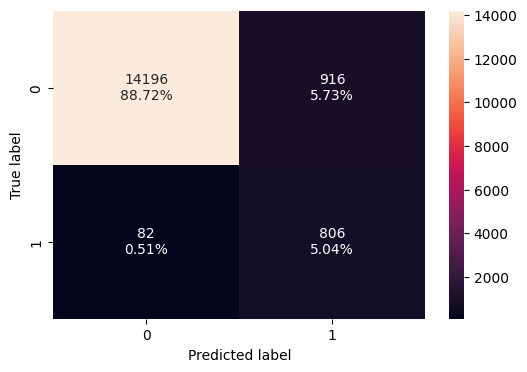


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step


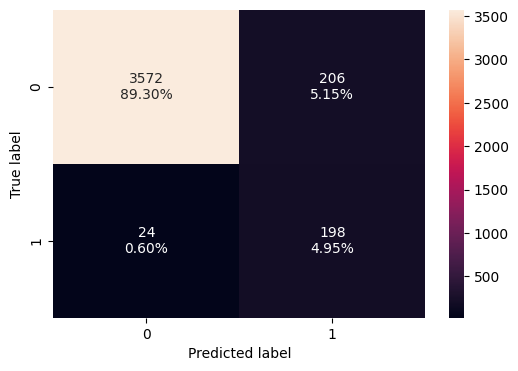

In [68]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_2, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_2, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 5.73% False Positives, 0.51% False negatives
* Validation
  - Confusion matrix shows around 5.15% False Positives, 0.60% False negatives


In [69]:
# Train Performance Metrics

model_2_train_perf = model_performance_classification(model_2, X_train, y_train)
model_2_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step


,Accuracy,Recall,Precision,F1 Score
0,0.937625,0.923522,0.731159,0.791834


In [70]:
# Validation Performance Metrics

model_2_valid_perf = model_performance_classification(model_2, X_val, y_val)
model_2_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9425,0.918683,0.741712,0.800699


**Observations:**

These performance metrics for "Model 2" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Model 2 achieved a Validation Recall of 0.918, a very slight increase from previous model
- Validation Precision fell to 0.741
- F1 score is slightly reduced to 0.800
- Accuracy is maintained at 93% for training and at 94% for validation metrics

*Not much difference in the overall metrics, with 50 epochs overall processing time almost doubled (~64 sec)*

### Model 3 - Increase batch_size (64)

- Include Class Weights to balance the imbalanced data
  - one hidden layer with 7 neurons
  - activation function of ReLU.
  - SGD as the optimizer
  - class weights
  - Increase Batch Size to 64
  - Remain Epochs to 25

In [71]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [72]:
#Initializing the neural network
model_3 = Sequential()
model_3.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model_3.add(Dense(1,activation="sigmoid"))

In [73]:
# Summary of the model configuration

model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# Define Optimiser and compile the model
optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used

# Compile with:
# 1. SGD Optimiser
# 2. Recall Metrics
model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 3 is a simple feedforward neural network with **1 hidden layer** (7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **SGD optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 295

In [75]:
# Fit the model with batch size as 64, Epochs as 25 and include class_weight

start = time.time()
history = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=64, epochs=25,class_weight=cw_dict)
end=time.time()

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6329 - loss: 1.1256 - val_Recall: 0.8694 - val_loss: 0.4206
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8798 - loss: 0.7168 - val_Recall: 0.8829 - val_loss: 0.3580
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8996 - loss: 0.6162 - val_Recall: 0.8829 - val_loss: 0.3246
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9058 - loss: 0.5658 - val_Recall: 0.8829 - val_loss: 0.3005
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9036 - loss: 0.5326 - val_Recall: 0.8829 - val_loss: 0.2836
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9045 - loss: 0.5123 - val_Recall: 0.8829 - val_loss: 0.2726
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.9026 - loss: 0.4990 - val_Recall: 0.8874 - val_loss: 0.2646
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Recall: 0.8918 - loss: 0.4886 - val_Recall: 0.8874 - val_loss: 0.2575
Epoch 9/

In [76]:
print("Time taken in seconds ",end-start)

Time taken in seconds  12.368161678314209


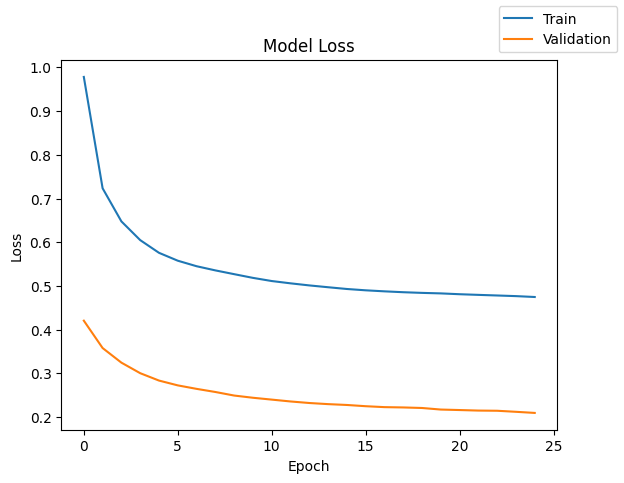

In [77]:
#Plot Model loss

plot(history,'loss')

**Note:** This shows significant gap between validation and training loss

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step


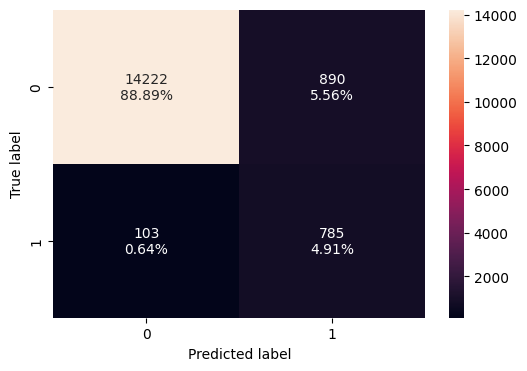


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step


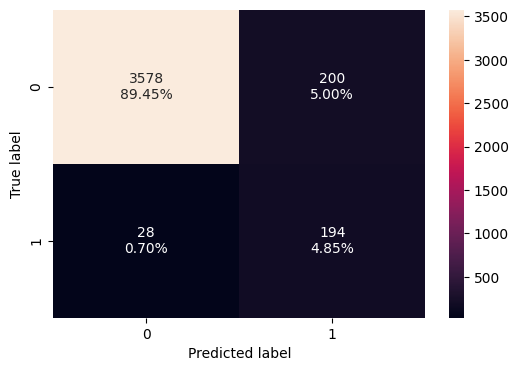

In [78]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_3, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_3, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 5.56% False Positives, 0.64% False negatives
* Validation
  - Confusion matrix shows around 5.00% False Positives, 0.70% False negatives


In [79]:
# Train Performance Metrics

model_3_train_perf = model_performance_classification(model_3, X_train, y_train)
model_3_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step


,Accuracy,Recall,Precision,F1 Score
0,0.937937,0.912558,0.730733,0.789415


In [80]:
# Validation Performance Metrics

model_3_valid_perf = model_performance_classification(model_3, X_val, y_val)
model_3_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step


,Accuracy,Recall,Precision,F1 Score
0,0.943,0.910468,0.74231,0.799496


**Observations:**

These performance metrics for "Model 3" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Model 3 achieved a Validation Recall of 0.910, a slight decrease from previous model
- Validation Precision is around 0.742
- F1 score is slightly reduced to 0.799
- Accuracy is maintained at 93% for training and at 94% for validation metrics

*Not much difference in the overall metrics, with 64 batch size overall performance showed a slight decrease*

#### **Based on the above analysis, we will stick with 25 epochs and 32 batch size**

In [81]:
# Define the batch size and epochs upfront to use the same values for all models

epochs = 25
batch_size = 32

### Model 4 - Add Hidden layer

- Add hidden layer to the current network
  - one hidden layer with 7 neurons
  - another hidden layer with 14 neurons
  - activation function of ReLU.
  - SGD as the optimizer
  - class weights
  - Batch Size as 32
  - Epochs as 25

In [82]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [83]:
#Initializing the neural network
model_4 = Sequential()
model_4.add(Dense(14,activation="relu", input_dim=X_train.shape[1])) #New hidden layer
model_4.add(Dense(7,activation="relu"))
model_4.add(Dense(1,activation="sigmoid"))

In [84]:
# Summary of the model configuration

model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used

# Compile with:
# 1. SGD Optimiser
# 2. Recall Metrics
model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 4 is a feedforward neural network with **2 hidden layer** (14 and 7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **SGD optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 687

In [86]:
# Fit the model

start = time.time()
history = model_4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8372 - loss: 0.9373 - val_Recall: 0.8784 - val_loss: 0.3630
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8952 - loss: 0.5469 - val_Recall: 0.8919 - val_loss: 0.2830
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9056 - loss: 0.4490 - val_Recall: 0.9009 - val_loss: 0.2484
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.9102 - loss: 0.4053 - val_Recall: 0.9054 - val_loss: 0.2320
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9117 - loss: 0.3825 - val_Recall: 0.9054 - val_loss: 0.2213
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.9128 - loss: 0.3683 - val_Recall: 0.9054 - val_loss: 0.2159
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9130 - loss: 0.3565 - val_Recall: 0.9054 - val_loss: 0.2126
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9111 - loss: 0.3483 - val_Recall: 0.9054 - val_loss: 0.2095
Epoch 9/

In [87]:
print("Time taken in seconds ",end-start)

Time taken in seconds  22.95703434944153


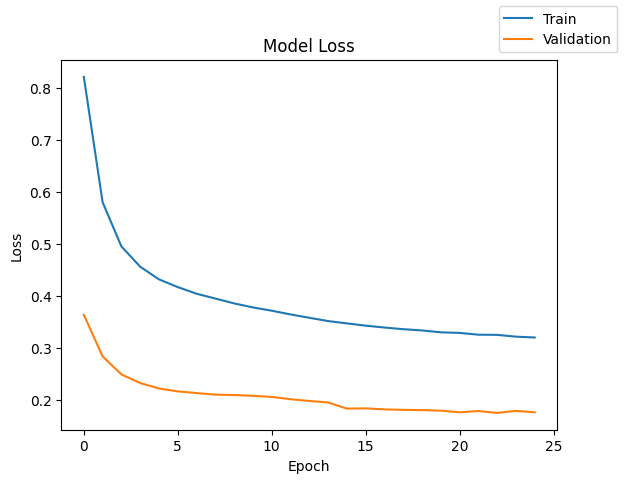

In [88]:
#Plot Model loss

plot(history,'loss')

**Note:** This shows slight significant gap between validation and training loss

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step


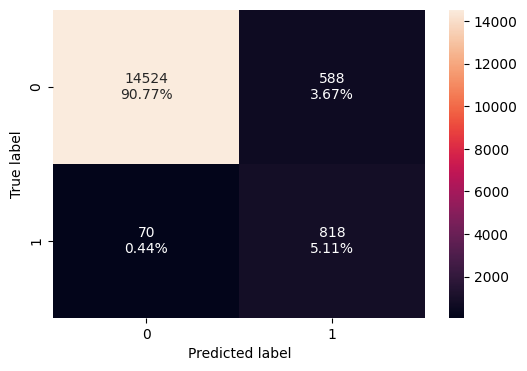


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step


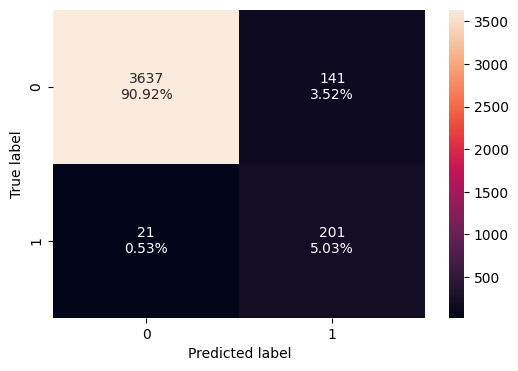

In [89]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_4, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_4, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 3.67% False Positives, 0.44% False negatives
* Validation
  - Confusion matrix shows around 3.52% False Positives, 0.53% False negatives


In [90]:
# Train Performance Metrics

model_4_train_perf = model_performance_classification(model_4, X_train, y_train)
model_4_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step


,Accuracy,Recall,Precision,F1 Score
0,0.958875,0.941131,0.788498,0.845507


In [91]:
# Validation Performance Metrics

model_4_valid_perf = model_performance_classification(model_4, X_val, y_val)
model_4_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9595,0.934042,0.790989,0.84549


**Observations:**

These performance metrics for "Model 4" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Adding a new layer increased the performance of the model
- Model 4 achieved a Validation Recall of 0.934, a good increase from previous model
- Validation Precision is around 0.79
- Validation F1 score is around 0.845
- Accuracy is maintained at 97% for training and at 97% for validation metrics

*Accuracy, Precision, F1 Score generalised well on training and validation sets, however Recall showed ~1% difference with training and validation data sets.*



Adding hidden layer improved performance a bit. Let's continue with this network

### Model 5 - Add momentum to SGD

- Add momentum to SGD
  - one hidden layer with 7 neurons
  - another hidden layer with 14 neurons
  - activation function of ReLU.
  - SGD Optimizer, with momentum
  - class weights
  - Batch Size as 32
  - Epochs as 25

In [92]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [93]:
#Initializing the neural network
model_5 = Sequential()
model_5.add(Dense(14,activation="relu", input_dim=X_train.shape[1]))
model_5.add(Dense(7,activation="relu"))
model_5.add(Dense(1,activation="sigmoid"))

In [94]:
# Summary of the model configuration

model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [195]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.SGD(momentum=0.8)    # defining SGD as the optimizer to be used, add momentum

# Compile with:
# 1. SGD Optimiser
# 2. Recall Metrics
model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 5 is a feedforward neural network with **2 hidden layer** (14 and 7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **SGD optimizer** is used as specified; with added momentum.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 687

In [96]:
# Fit the model

start = time.time()
history = model_5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.9014 - loss: 0.8665 - val_Recall: 0.8829 - val_loss: 0.3074
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8938 - loss: 0.4334 - val_Recall: 0.8874 - val_loss: 0.2146
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9026 - loss: 0.3794 - val_Recall: 0.8919 - val_loss: 0.1842
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.9050 - loss: 0.3462 - val_Recall: 0.9009 - val_loss: 0.1899
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9037 - loss: 0.3421 - val_Recall: 0.9009 - val_loss: 0.1754
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9081 - loss: 0.3236 - val_Recall: 0.8964 - val_loss: 0.1700
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9077 - loss: 0.3046 - val_Recall: 0.9054 - val_loss: 0.1748
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9133 - loss: 0.3049 - val_Recall: 0.9009 - val_loss: 0.1680
Epoch 9/

In [97]:
print("Time taken in seconds ",end-start)

Time taken in seconds  24.09499430656433


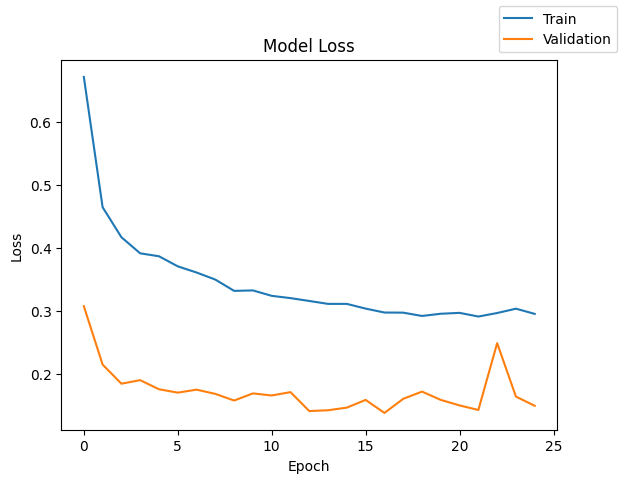

In [98]:
#Plot Model loss

plot(history,'loss')

**Note:** Validation loss fluctuates after 20 Epochs

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step


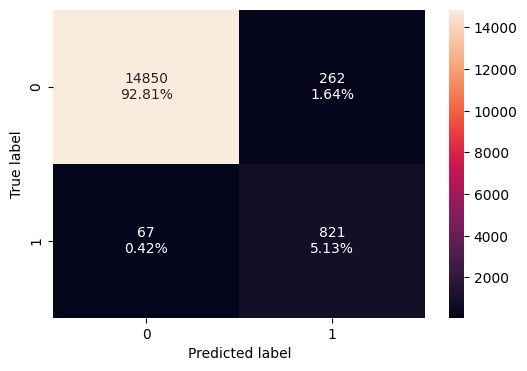


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step


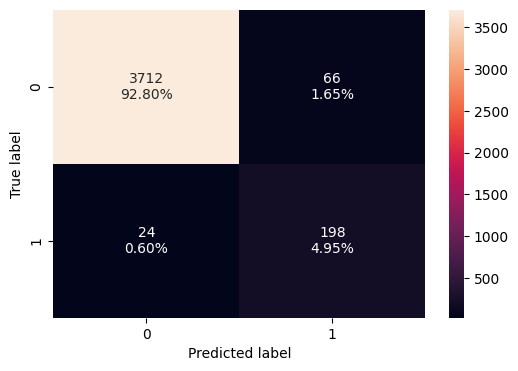

In [99]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_5, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_5, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 1.64% False Positives, 0.42% False negatives
* Validation
  - Confusion matrix shows around 1.65% False Positives, 0.60% False negatives


In [100]:
# Train Performance Metrics

model_5_train_perf = model_performance_classification(model_5, X_train, y_train)
model_5_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step


,Accuracy,Recall,Precision,F1 Score
0,0.979437,0.953606,0.876794,0.911062


In [101]:
# Validation Performance Metrics

model_5_valid_perf = model_performance_classification(model_5, X_val, y_val)
model_5_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9775,0.937211,0.871788,0.901419


**Observations:**

These performance metrics for "Model 5" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Adding momentum to SGD caused improvement in the performance of the model
- Model 5 achieved a Validation Recall of 0.937
- Validation Precision increased to 0.87
- Validation F1 score is increased to 0.90
- Accuracy is maintained at 98% for training and at 98% for validation metrics

*There's a good improvment in the performance of the model, however Recall, F1 score showed ~2% difference with training and validation data sets.*

### Model 6 - Adam Optimizer

- Let's change the optimizer to Adam
  - one hidden layer with 7 neurons
  - another hidden layer with 14 neurons
  - activation function of ReLU.
  - Adam Optimizer
  - class weights
  - Batch Size as 32
  - Epochs as 25

In [102]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [103]:
#Initializing the neural network
model_6 = Sequential()
model_6.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_6.add(Dense(7,activation="relu"))
model_6.add(Dense(1,activation="sigmoid"))

In [104]:
# Summary of the model configuration

model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 6 is a feedforward neural network with **2 hidden layer** (14 and 7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **Adam optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 687

In [106]:
# Fit the model

start = time.time()
history = model_6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.8173 - loss: 0.9833 - val_Recall: 0.8694 - val_loss: 0.3521
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8877 - loss: 0.5564 - val_Recall: 0.8829 - val_loss: 0.2730
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9029 - loss: 0.4630 - val_Recall: 0.8964 - val_loss: 0.2424
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9079 - loss: 0.4088 - val_Recall: 0.9009 - val_loss: 0.2261
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9049 - loss: 0.3793 - val_Recall: 0.9009 - val_loss: 0.1977
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9071 - loss: 0.3597 - val_Recall: 0.9009 - val_loss: 0.1771
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9081 - loss: 0.3445 - val_Recall: 0.9009 - val_loss: 0.1636
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9080 - loss: 0.3294 - val_Recall: 0.9009 - val_loss: 0.1569
Epoch 9/

In [107]:
print("Time taken in seconds ",end-start)

Time taken in seconds  25.2752103805542


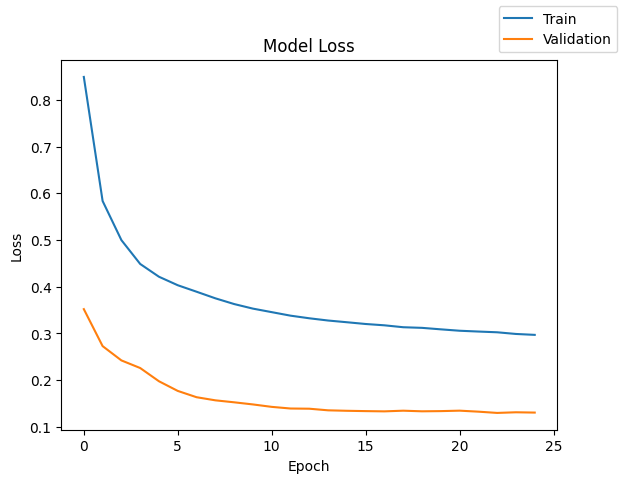

In [108]:
#Plot Model loss

plot(history,'loss')

**Note:** This shows a significant gap between training and validation loss

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step


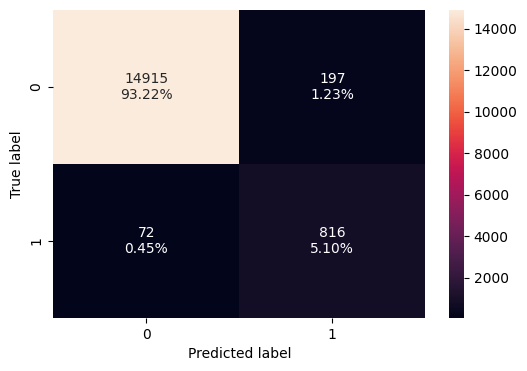


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


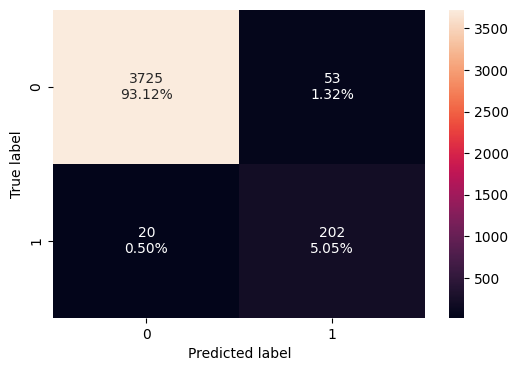

In [109]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_6, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_6, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 1.23% False Positives, 0.45% False negatives
* Validation
  - Confusion matrix shows around 1.32% False Positives, 0.50% False negatives


In [110]:
# Train Performance Metrics

model_6_train_perf = model_performance_classification(model_6, X_train, y_train)
model_6_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


,Accuracy,Recall,Precision,F1 Score
0,0.983187,0.952941,0.900362,0.924779


In [111]:
# Validation Performance Metrics

model_6_valid_perf = model_performance_classification(model_6, X_val, y_val)
model_6_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98175,0.947941,0.893408,0.918628


**Observations:**

These performance metrics for "Model 6" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Adam optimiser shows improvement
- Model 6 achieved a Validation Recall of 0.947, which is the good performance.
- Validation Precision is now 0.89
- Validation F1 score is around 0.91
- Accuracy is maintained at 98% for training and at 98% for validation metrics

*This is a better performance(Recall and Precision) compared with SGD*

### Model 7 - RMSprop Optimiser

- Let's try with RMSprop optimizer
  - one hidden layer with 7 neurons
  - another hidden layer with 14 neurons
  - activation function of ReLU.
  - RMSProp Optimizer
  - class weights
  - Batch Size as 32
  - Epochs as 25

In [112]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [113]:
#Initializing the neural network
model_7 = Sequential()
model_7.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_7.add(Dense(7,activation="relu"))
model_7.add(Dense(1,activation="sigmoid"))

In [114]:
# Summary of the model configuration

model_7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [115]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.RMSprop() #RMSprop Optimizer
model_7.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 7 is a feedforward neural network with **2 hidden layer** (14 and 7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **RMSprop optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 687

In [116]:
# Fit the model

start = time.time()
history = model_7.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.9082 - loss: 1.0539 - val_Recall: 0.8604 - val_loss: 0.4634
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.8742 - loss: 0.6062 - val_Recall: 0.8559 - val_loss: 0.2323
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8736 - loss: 0.4734 - val_Recall: 0.8694 - val_loss: 0.1944
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8870 - loss: 0.4353 - val_Recall: 0.8739 - val_loss: 0.1743
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8846 - loss: 0.4124 - val_Recall: 0.8739 - val_loss: 0.1612
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8903 - loss: 0.3971 - val_Recall: 0.8739 - val_loss: 0.1510
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8938 - loss: 0.3852 - val_Recall: 0.8784 - val_loss: 0.1446
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Recall: 0.8955 - loss: 0.3744 - val_Recall: 0.8829 - val_loss: 0.1391
Epoch 9/

In [117]:
print("Time taken in seconds ",end-start)

Time taken in seconds  23.390695095062256


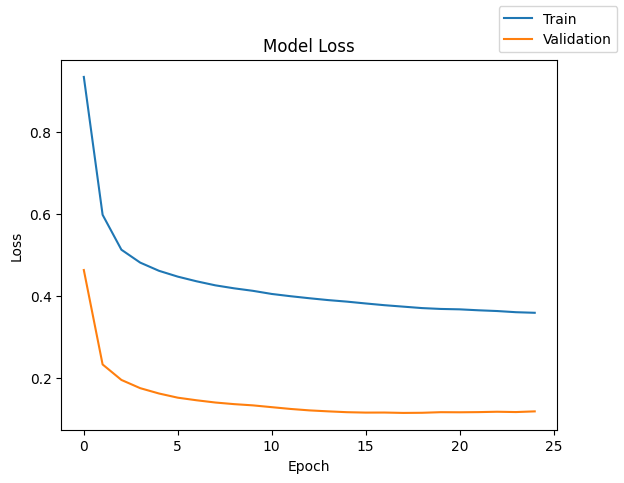

In [118]:
#Plot Model loss

plot(history,'loss')

**Note:** This shows a significant gap between training and validation loss

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


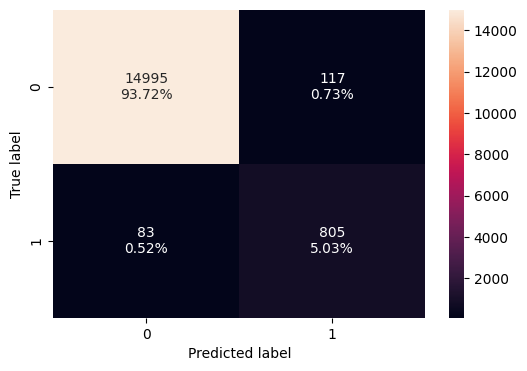


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step


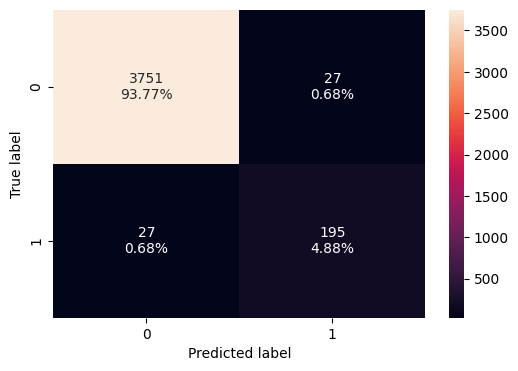

In [119]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_7, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_7, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 0.73% False Positives, 0.52% False negatives
* Validation
  - Confusion matrix shows around 0.68% False Positives, 0.68% False negatives


In [120]:
# Train Performance Metrics

model_7_train_perf = model_performance_classification(model_7, X_train, y_train)
model_7_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9875,0.949395,0.933799,0.941439


In [121]:
# Validation Performance Metrics

model_7_valid_perf = model_performance_classification(model_7, X_val, y_val)
model_7_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9865,0.935616,0.935616,0.935616


**Observations:**

These performance metrics for "Model 7" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- RMS optimiser shows mixed improvement from Adam
- Model 7 achieved a Validation Recall of 0.935, which is less compared with Adam.
- Validation Precision is now 0.93 (this is way higher than other models)
- F1 score is around 0.94 (Increase in F1 score)
- Accuracy is maintained at 98.7% for training and at 98.6% for validation metrics

*Seems this optimizer improved Precision more compared with recall*

### Best Optimizer

Adam Optimiser (0.947 Recall) showed better performance on validation dataset compared with others, going forward we will use Adam Optimizer for further analysis


### Model 8 - Adam Optimiser with New hidden layers

- Add another hidden layer (21 neurons)
  - one hidden layer with 7 neurons
  - another hidden layer with 14 neurons
  - activation function of ReLU.
  - Adam Optimizer
  - class weights
  - Batch Size as 32
  - Epochs as 25

In [122]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [123]:
#Initializing the neural network
model_8 = Sequential()
model_8.add(Dense(21,activation="relu",input_dim=X_train.shape[1])) # New hidden layer
model_8.add(Dense(14,activation="relu"))
model_8.add(Dense(7,activation="relu"))
model_8.add(Dense(1,activation="sigmoid"))

In [124]:
# Summary of the model configuration

model_8.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 21)             │           861 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.Adam()
model_8.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 8 is a feedforward neural network with **3 hidden layer** (21, 14 and 7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **Adam optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 1282

In [126]:
# Fit the model

start = time.time()
history = model_8.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.7165 - loss: 0.9448 - val_Recall: 0.9054 - val_loss: 0.3570
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8951 - loss: 0.4911 - val_Recall: 0.8874 - val_loss: 0.2457
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8968 - loss: 0.3931 - val_Recall: 0.8919 - val_loss: 0.2137
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9029 - loss: 0.3510 - val_Recall: 0.8919 - val_loss: 0.2024
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9077 - loss: 0.3271 - val_Recall: 0.8964 - val_loss: 0.1950
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9105 - loss: 0.3076 - val_Recall: 0.9009 - val_loss: 0.1872
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9166 - loss: 0.2926 - val_Recall: 0.9009 - val_loss: 0.1805
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9208 - loss: 0.2802 - val_Recall: 0.9009 - val_loss: 0.1809
Epoch 9/

In [127]:
print("Time taken in seconds ",end-start)

Time taken in seconds  25.08984637260437


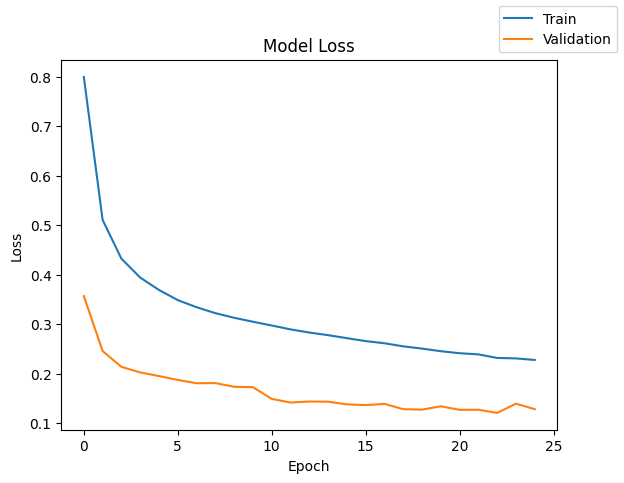

In [128]:
#Plot Model loss

plot(history,'loss')

**Note:** The gap between training and validation loss is gradually decreasing

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step


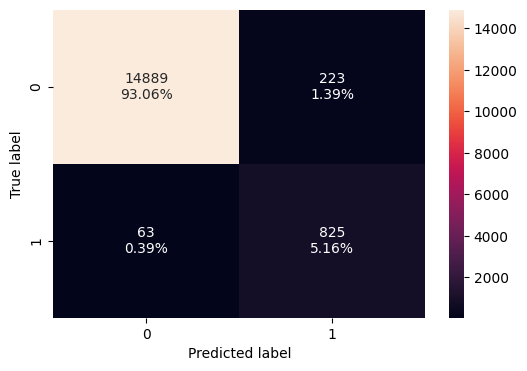


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step


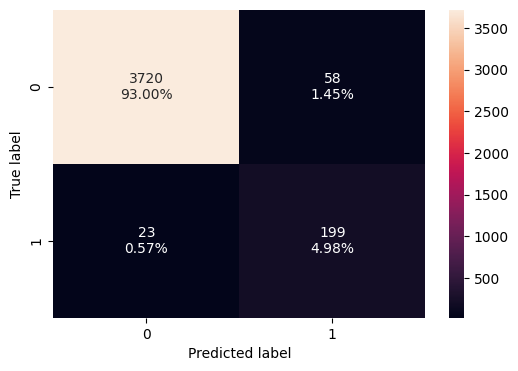

In [129]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_8, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_8, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 1.39% False Positives, 0.39% False negatives
* Validation
  - Confusion matrix shows around 1.45% False Positives, 0.57% False negatives


In [130]:
# Train Performance Metrics

model_8_train_perf = model_performance_classification(model_8, X_train, y_train)
model_8_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step


,Accuracy,Recall,Precision,F1 Score
0,0.982125,0.957149,0.8915,0.92138


In [131]:
# Validation Performance Metrics

model_8_valid_perf = model_performance_classification(model_8, X_val, y_val)
model_8_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step


,Accuracy,Recall,Precision,F1 Score
0,0.97975,0.940522,0.884087,0.910064


**Observations:**

These performance metrics for "Model 8" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Model 8 achieved a Validation Recall of 0.94, which is good.
- Validation Precision is now 0.88
- Validation F1 score is around 0.91
- Accuracy is maintained at 98.2% for training and at 97.9% for validation metrics

*Model with additional layer also shows good recall with acceptable precision*

### Model 9 - Adam Optimiser with Drop Outs

- Introduce Dropout for regularization
  - one hidden layer with 7 neurons
  - another hidden layer with 14 neurons
  - another hidden layer (21 neurons)
  - activation function of ReLU.
  - Adam Optimizer
  - class weights
  - Batch Size as 32
  - Epochs as 25

In [132]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [133]:
#Initializing the neural network
model_9 = Sequential()
model_9.add(Dense(21,activation="relu",input_dim=X_train.shape[1]))
model_9.add(Dropout(0.3)) # 30% drop out
model_9.add(Dense(14,activation="relu"))
model_9.add(Dropout(0.1)) # 10% drop out
model_9.add(Dense(7,activation="relu"))
model_9.add(Dropout(0.1)) # 10% drop out
model_9.add(Dense(1,activation="sigmoid"))

In [134]:
# Summary of the model configuration

model_9.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 21)             │           861 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

In [135]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.Adam()
model_9.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 9 is a feedforward neural network with **3 hidden layer** (21, 14 and 7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **Adam optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 1282
- Droputs are added after every hidden layer for regularization

In [136]:
# Fit the model

start = time.time()
history = model_9.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.8251 - loss: 1.2400 - val_Recall: 0.9234 - val_loss: 0.4774
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8670 - loss: 0.7296 - val_Recall: 0.8874 - val_loss: 0.3010
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8636 - loss: 0.6025 - val_Recall: 0.8874 - val_loss: 0.2250
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8453 - loss: 0.5711 - val_Recall: 0.8964 - val_loss: 0.2102
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.8566 - loss: 0.5405 - val_Recall: 0.8919 - val_loss: 0.1998
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8588 - loss: 0.5055 - val_Recall: 0.8919 - val_loss: 0.1841
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8765 - loss: 0.4973 - val_Recall: 0.8919 - val_loss: 0.1682
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8805 - loss: 0.4558 - val_Recall: 0.8829 - val_loss: 0.1681
Epoch 9/

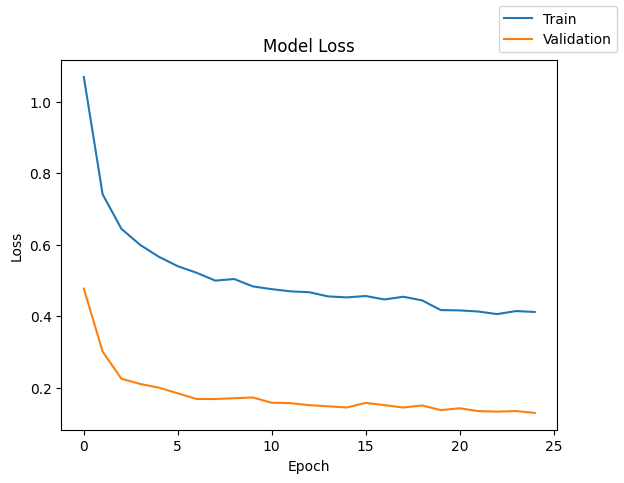

In [137]:
plot(history,'loss')

**Note:** Significance gap is observed between validation and training loss

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step


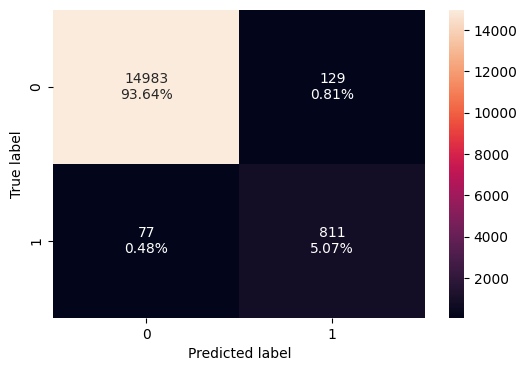


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step


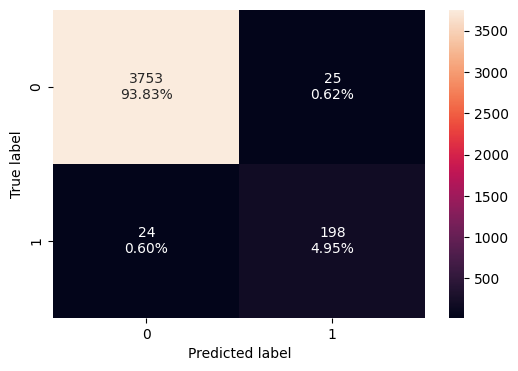

In [138]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_9, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_9, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 0.81% False Positives, 0.48% False negatives
* Validation
  - Confusion matrix shows around 0.62% False Positives, 0.60% False negatives


In [139]:
# Train Performance Metrics

model_9_train_perf = model_performance_classification(model_9, X_train, y_train)
model_9_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.987125,0.952376,0.928827,0.940241


In [140]:
# Test Performance Metrics

model_9_valid_perf = model_performance_classification(model_9, X_val, y_val)
model_9_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98775,0.942637,0.940769,0.941701


**Observations:**

These performance metrics for "Model 9" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- This model shows good performance on drop outs
- Model 9 achieved a Validation Recall of 0.942, a good increase
- Validation Precision is around 0.94
- Validation F1 score is increased to 0.941
- Accuracy is maintained at 98% for training and at 98% for validation metrics

*Adding DropOuts showed slight improvement in the performance*

### Model 10 - Adam Optimiser with Batch Normalization

- Introduce Batch Normalization
  - one hidden layer with 7 neurons
  - another hidden layer with 14 neurons
  - another hidden layer (21 neurons)
  - activation function of ReLU.
  - Adam Optimizer
  - class weights
  - Batch Size as 32
  - Epochs as 25

In [141]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [142]:
#Initializing the neural network
model_10 = Sequential()
model_10.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model_10.add(BatchNormalization())
model_10.add(Dense(7,activation="relu"))
model_10.add(BatchNormalization())
model_10.add(Dense(1,activation="sigmoid"))

In [143]:
# Summary of the model configuration

model_10.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7)              │            28 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771 (3.01 KB)

 Trainable params: 729 (2.85 KB)

 Non-trainable params: 42 (168.00 B)

In [144]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.Adam()
model_10.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 10 is a feedforward neural network with **3 hidden layer** (21, 14 and 7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **Adam optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total trainable parameters are around 729
- Batch Normalization is added after every hidden layer for regularization

In [145]:
# Fit the model
start = time.time()
history = model_10.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.7236 - loss: 1.2650 - val_Recall: 0.8829 - val_loss: 0.4120
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9038 - loss: 0.6623 - val_Recall: 0.8784 - val_loss: 0.2811
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9011 - loss: 0.5295 - val_Recall: 0.8874 - val_loss: 0.2348
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9062 - loss: 0.4635 - val_Recall: 0.8829 - val_loss: 0.2112
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9085 - loss: 0.4287 - val_Recall: 0.8919 - val_loss: 0.1827
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9129 - loss: 0.4021 - val_Recall: 0.8964 - val_loss: 0.1720
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9199 - loss: 0.3815 - val_Recall: 0.8829 - val_loss: 0.1663
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9165 - loss: 0.3623 - val_Recall: 0.8919 - val_loss: 0.1611
Epoch 9/

In [146]:
print("Time taken in seconds ",end-start)

Time taken in seconds  27.184131860733032


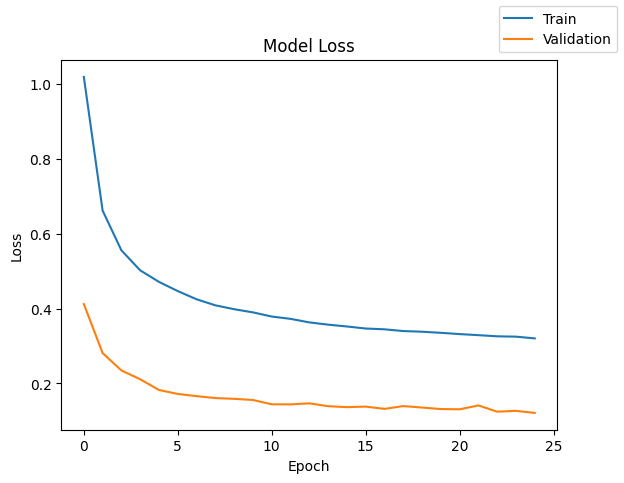

In [147]:
#Plot Model loss
plot(history,'loss')

**Note:** Significant gap is present between validation and train loss

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step


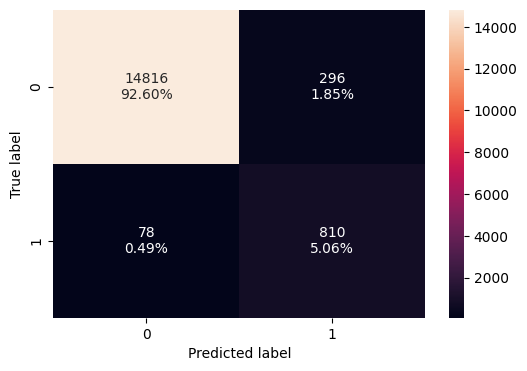


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step


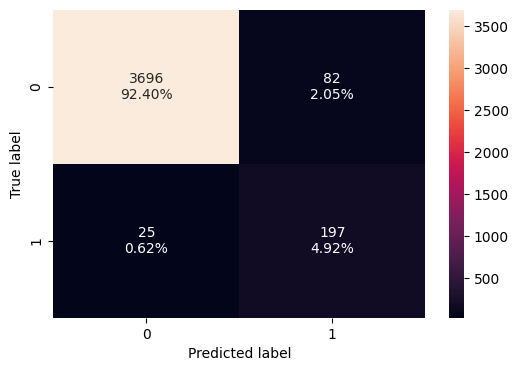

In [148]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_10, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_10, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 1.85% False Positives, 0.49% False negatives
* Validation
  - Confusion matrix shows around 2.05% False Positives, 0.62% False negatives


In [149]:
# Train Performance Metrics

model_10_train_perf = model_performance_classification(model_10, X_train, y_train)
model_10_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step


,Accuracy,Recall,Precision,F1 Score
0,0.976625,0.946288,0.863566,0.899987


In [150]:
# Validation Performance Metrics

model_10_valid_perf = model_performance_classification(model_10, X_val, y_val)
model_10_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step


,Accuracy,Recall,Precision,F1 Score
0,0.97325,0.932841,0.849687,0.886079


**Observations:**

These performance metrics for "Model 10" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Add batch normalization didn't improve much performance of the model
- Model 10 achieved a Validation Recall of 0.932, reduced by a bit compared with previous model
- Validation Precision reduced to 0.849
- Validation F1 score is around to 0.886
- Accuracy is maintained at 97% for training and at 97% for validation metrics

*Generalisation of the model reduced a bit in this process*

### Model 11 - Adam Optimiser with Dropouts and Batch Normalization

- Introduce Batch Normalization and Dropouts
  - one hidden layer with 7 neurons
  - another hidden layer with 14 neurons
  - another hidden layer (21 neurons)
  - activation function of ReLU.
  - Adam Optimizer
  - class weights
  - Batch Size as 32
  - Epochs as 25

In [151]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [152]:
#Initializing the neural network
model_11 = Sequential()
model_11.add(Dense(21,activation="relu",input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model_11.add(Dropout(0.3))
model_11.add(Dense(14,activation="relu"))
model.add(BatchNormalization())
model_11.add(Dropout(0.1))
model_11.add(Dense(7,activation="relu"))
model.add(BatchNormalization())
model_11.add(Dropout(0.1))
model_11.add(Dense(1,activation="sigmoid"))

We apply Batch Normalization (BN) before Dropout ensures that the inputs to the activation function are properly normalized, while applying Dropout afterward adds regularization to those stabilized activations

In [153]:
# Summary of the model configuration
model_11.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 21)             │           861 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

**Observations:**
- Model 11 is a feedforward neural network with **3 hidden layer** (21, 14 and 7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **Adam optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 1282
- Batch Normalization is added for every hidden layer
- Dropouts are added after every hidden layer for regularization

In [154]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.Adam()
model_11.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

In [155]:
# Fit the model

start = time.time()
history = model_11.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.7925 - loss: 1.1042 - val_Recall: 0.8874 - val_loss: 0.3658
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8809 - loss: 0.6486 - val_Recall: 0.8874 - val_loss: 0.2636
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8660 - loss: 0.5897 - val_Recall: 0.8919 - val_loss: 0.2528
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8742 - loss: 0.5250 - val_Recall: 0.8829 - val_loss: 0.1991
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.8731 - loss: 0.4816 - val_Recall: 0.8784 - val_loss: 0.2002
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8681 - loss: 0.4835 - val_Recall: 0.8829 - val_loss: 0.1806
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8791 - loss: 0.4526 - val_Recall: 0.8874 - val_loss: 0.1795
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8867 - loss: 0.4583 - val_Recall: 0.8964 - val_loss: 0.1701
Epoch 9/

In [156]:
print("Time taken in seconds ",end-start)

Time taken in seconds  27.983381271362305


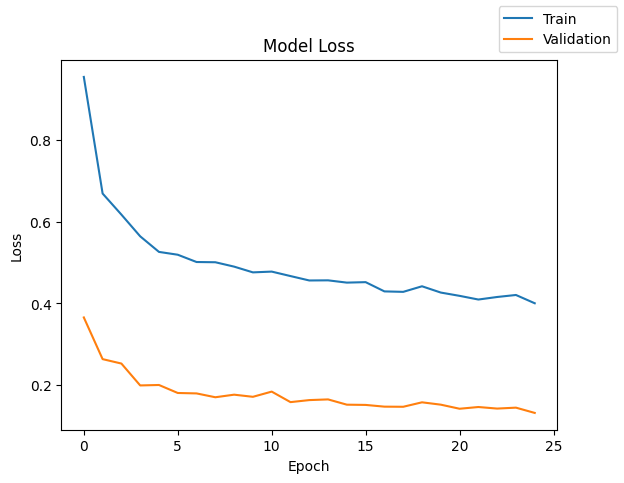

In [157]:
plot(history,'loss')

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step


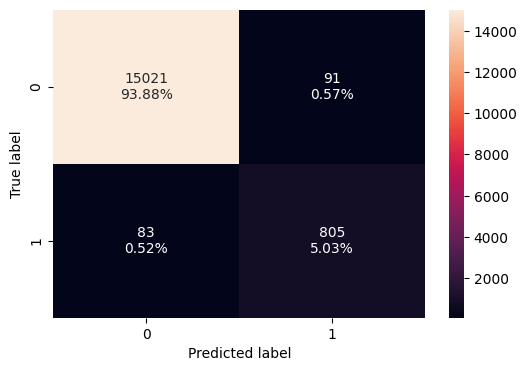


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


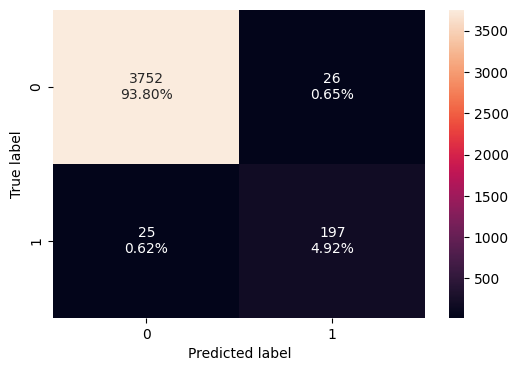

In [158]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_11, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_11, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 0.57% False Positives, 0.52% False negatives
* Validation
  - Confusion matrix shows around 0.65% False Positives, 0.62% False negatives


In [159]:
# Train Performance Metrics

model_11_train_perf = model_performance_classification(model_11, X_train, y_train)
model_11_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.989125,0.950255,0.946471,0.948354


In [160]:
# Validation Performance Metrics

model_11_valid_perf = model_performance_classification(model_11, X_val, y_val)
model_11_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step


,Accuracy,Recall,Precision,F1 Score
0,0.98725,0.940253,0.938395,0.939321


**Observations:**

These performance metrics for "Model 11" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Adding a new layer increased the performance of the model
- Model 11 achieved a Validation Recall of 0.940, a good score.
- Validation Precision is around 0.93
- Validation F1 score is around 0.93
- Accuracy is maintained at 98% for training and at 98% for validation metrics

*It looks like the model is trying to improve precision more compared with Recall. however Recall, F1 score showed ~1% difference with training and validation data sets.*

### Model 12 - Adam Optimizer with (Wt) Initialisation

- Introduce Weights initialization that helps in learning of the model
  - one hidden layer with 7 neurons
  - another hidden layer with 14 neurons
  - another hidden layer (21 neurons)
  - activation function of ReLU.
  - Adam Optimizer
  - class weights
  - Batch Size as 32
  - Epochs as 25

In [161]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [162]:
#Initializing the neural network
model_12 = Sequential()
model_12.add(Dense(21,activation="relu",kernel_initializer='he_normal',input_dim=X_train.shape[1])) # He Normal is the method for initialising weights
model_12.add(Dense(14,activation="relu", kernel_initializer='he_normal'))
model_12.add(Dense(7,activation="relu", kernel_initializer='he_normal'))
model_12.add(Dense(1,activation="sigmoid"))

In [163]:
# Summary of the model configuration

model_12.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 21)             │           861 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

In [164]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model_12.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 12 is a feedforward neural network with **3 hidden layer** (21, 14 and 7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **Adam optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- **He Initialization** is added to ReLU activation for hidden layers
- Total parameters are around 1282

In [165]:
# Fit the model

start = time.time()
history = model_12.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.7388 - loss: 0.9688 - val_Recall: 0.9054 - val_loss: 0.3930
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9004 - loss: 0.5103 - val_Recall: 0.9144 - val_loss: 0.3073
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9058 - loss: 0.4125 - val_Recall: 0.9054 - val_loss: 0.2757
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9073 - loss: 0.3705 - val_Recall: 0.9099 - val_loss: 0.2444
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9115 - loss: 0.3451 - val_Recall: 0.9099 - val_loss: 0.2581
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9122 - loss: 0.3297 - val_Recall: 0.9099 - val_loss: 0.2511
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9188 - loss: 0.3163 - val_Recall: 0.9099 - val_loss: 0.2411
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.9205 - loss: 0.3066 - val_Recall: 0.9054 - val_loss: 0.2318
Epoch 9/

In [166]:
print("Time taken in seconds ",end-start)

Time taken in seconds  26.3394513130188


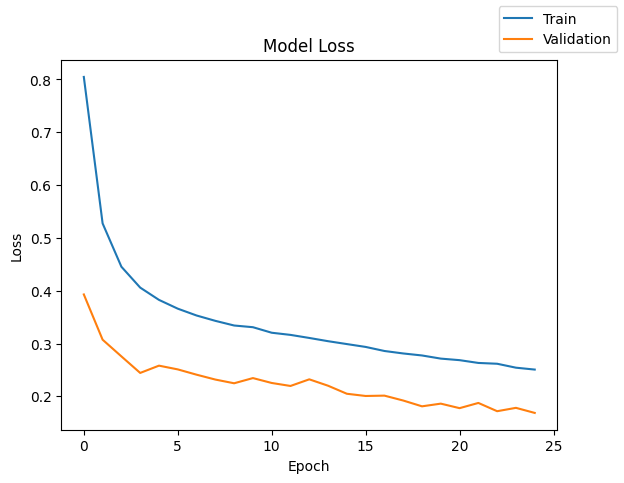

In [167]:
#Plot Model loss

plot(history,'loss')

**Note:** It can be observed that the loss gap is gradually reducing between validation and training sets

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step


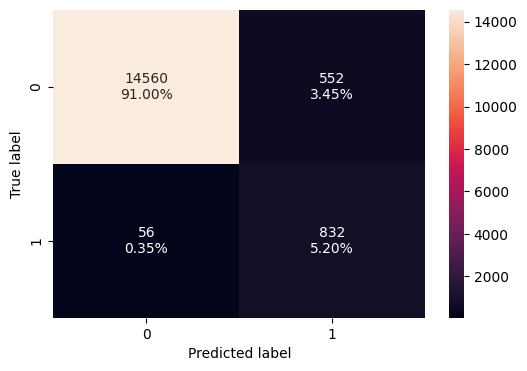


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step


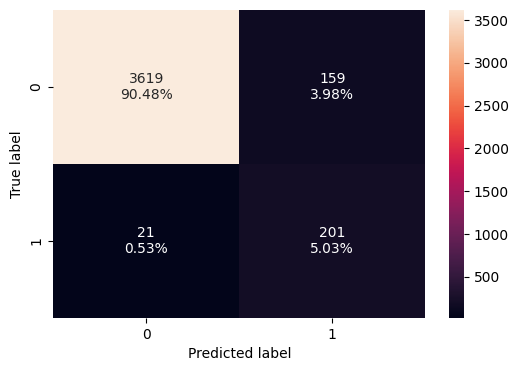

In [168]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_12, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_12, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 3.45% False Positives, 0.35% False negatives
* Validation
  - Confusion matrix shows around 3.98% False Positives, 0.53% False negatives


In [169]:
# Train Performance Metrics

model_12_train_perf = model_performance_classification(model_12, X_train, y_train)
model_12_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step


,Accuracy,Recall,Precision,F1 Score
0,0.962,0.950205,0.798662,0.855971


In [170]:
# Validation Performance Metrics

model_12_valid_perf = model_performance_classification(model_12, X_val, y_val)
model_12_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step


,Accuracy,Recall,Precision,F1 Score
0,0.955,0.93166,0.776282,0.833228


**Observations:**

These performance metrics for "Model 12" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Adding weight initializer impacted precision and F1 score
- Model 12 achieved a Validation Recall of 0.931, which is the good performance.
- However, Validation Precision is dropped to 0.77
- Validation F1 score is dropped to 0.83
- Accuracy is maintained at 96% for training and at 95% for validation metrics

*The model with the initializer might be providing too much initial variance causing the model to overfit. Gap between training and validation metrics is around ~2%, showing generalisation issue.*

### Model 13 - Adam Optimizer with (Wt) Initialization and Drop Out

- Introduce Weights initialization that helps in learning of the model
  - one hidden layer with 7 neurons
  - another hidden layer with 14 neurons
  - another hidden layer (21 neurons)
  - activation function of ReLU.
  - Adam Optimizer
  - class weights
  - Batch Size as 32
  - Epochs as 25
  - Dropouts are added

In [171]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [172]:
#Initializing the neural network
model_13 = Sequential()
model_13.add(Dense(21,activation="relu",kernel_initializer='he_normal',input_dim=X_train.shape[1]))
model_13.add(Dropout(0.3))
model_13.add(Dense(14,activation="relu", kernel_initializer='he_normal'))
model_13.add(Dropout(0.1))
model_13.add(Dense(7,activation="relu", kernel_initializer='he_normal'))
model_13.add(Dropout(0.1))
model_13.add(Dense(1,activation="sigmoid"))

In [173]:
# Summary of the model configuration

model_13.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 21)             │           861 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

In [174]:
# Define Optimiser and compile the model

optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model_13.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

**Observations:**
- Model 13 is a feedforward neural network with **3 hidden layer** (21, 14 and 7 neurons) using ReLU activation.
- The output layer uses **sigmoid activation** for binary classification.
- **Adam optimizer** is used as specified.
- **Binary cross-entropy** is the appropriate loss function for binary classification.
- Total parameters are around 1282
- **He Initialization** is added to ReLU activation for hidden layers
- Droputs are added after every hidden layer for regularization

In [175]:
# Fit the model

start = time.time()
history = model_13.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.5415 - loss: 1.2888 - val_Recall: 0.9009 - val_loss: 0.5094
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8016 - loss: 0.9270 - val_Recall: 0.8829 - val_loss: 0.3963
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8344 - loss: 0.7365 - val_Recall: 0.8874 - val_loss: 0.3460
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.8589 - loss: 0.6357 - val_Recall: 0.8739 - val_loss: 0.2866
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.8733 - loss: 0.5842 - val_Recall: 0.8784 - val_loss: 0.2439
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8581 - loss: 0.5841 - val_Recall: 0.8784 - val_loss: 0.2645
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8743 - loss: 0.4878 - val_Recall: 0.8739 - val_loss: 0.1935
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8698 - loss: 0.4775 - val_Recall: 0.8874 - val_loss: 0.2051
Epoch 9/

In [176]:
print("Time taken in seconds ",end-start)

Time taken in seconds  30.522597789764404


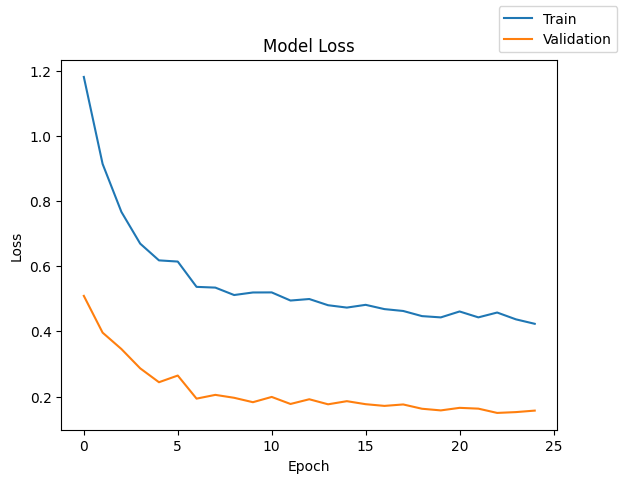

In [177]:
#Plot Model loss

plot(history,'loss')

Train Confusion Matrix

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


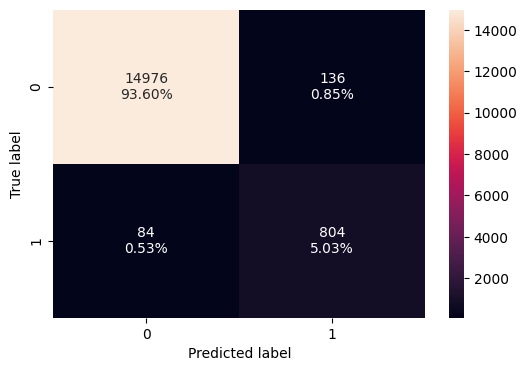


Validation Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step


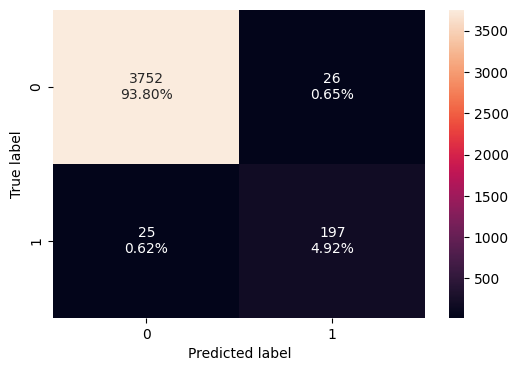

In [178]:
# Plot 'train' confusion matrix

print('Train Confusion Matrix\n')
confusion_matrix_sklearn(model_13, X_train, y_train)

print('\nValidation Confusion Matrix\n')
confusion_matrix_sklearn(model_13, X_val, y_val)

**Observations:**

This Confusion Matrix provides a detailed breakdown of the model's performance:

* Training
  - Confusion matrix shows around 0.85% False Positives, 0.53% False negatives
* Validation
  - Confusion matrix shows around 0.65% False Positives, 0.62% False negatives


In [179]:
# Train Performance Metrics

model_13_train_perf = model_performance_classification(model_13, X_train, y_train)
model_13_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step


,Accuracy,Recall,Precision,F1 Score
0,0.98625,0.948203,0.924871,0.936179


In [180]:
# Validation Performance Metrics

model_13_valid_perf = model_performance_classification(model_13, X_val, y_val)
model_13_valid_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Accuracy,Recall,Precision,F1 Score
0,0.98725,0.940253,0.938395,0.939321


**Observations:**

These performance metrics for "Model 13" across the training and validation sets offer a clear picture of how the classifier is handling the failure prediction task.

- Model 6 achieved a Validation Recall of 0.940, which is the good performance.
- Validation Precision is around 0.93
- Validation F1 score is around 0.93
- Accuracy is maintained at 98% for training and at 98% for validation metrics

*Gap between training and validation metrics is around ~1%. Precision improved better in validation dataset, compared with Recall*

### Model Performance Comparison and Final Model Selection

Let's compare training and validation set performances and select final model

In [198]:
# Create a dataframe of train set performances

models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T,
        model_7_train_perf.T,
        model_8_train_perf.T,
        model_9_train_perf.T,
        model_10_train_perf.T,
        model_11_train_perf.T,
        model_12_train_perf.T,
        model_13_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "NN (1 Hidden layer, SGD, No Class Weights)",
    "NN (1 Hidden layer, SGD, Class Weights)",
    "NN (1 Hidden layer, SGD, Epochs (50))",
    "NN (1 Hidden layer, SGD, BatchSize (64)))",
    "NN (2 Hidden layers, SGD)",
    "NN (2 Hidden layers, SGD (Momentum))",
    "NN (2 Hidden layers, Adam)",
    "NN (2 Hidden layers, RMSprop)",
    "NN (3 Hidden layers, Adam)",
    "NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1])",
    "NN (3 Hidden layers, Adam, Batch Normalization)",
    "NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1], Batch Normalization)",
    "NN (3 Hidden layers, Adam, He Initialization)",
    "NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1], He Initialization)"
]

In [199]:
# Create a dataframe of val set performances
models_val_comp_df = pd.concat(
    [
        model_0_valid_perf.T,
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T,
        model_5_valid_perf.T,
        model_6_valid_perf.T,
        model_7_valid_perf.T,
        model_8_valid_perf.T,
        model_9_valid_perf.T,
        model_10_valid_perf.T,
        model_11_valid_perf.T,
        model_12_valid_perf.T,
        model_13_valid_perf.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "NN (1 Hidden layer, SGD, No Class Weights)",
    "NN (1 Hidden layer, SGD, Class Weights)",
    "NN (1 Hidden layer, SGD, Epochs (50))",
    "NN (1 Hidden layer, SGD, BatchSize (64)))",
    "NN (2 Hidden layers, SGD)",
    "NN (2 Hidden layers, SGD (Momentum))",
    "NN (2 Hidden layers, Adam)",
    "NN (2 Hidden layers, RMSprop)",
    "NN (3 Hidden layers, Adam)",
    "NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1])",
    "NN (3 Hidden layers, Adam, Batch Normalization)",
    "NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1], Batch Normalization)",
    "NN (3 Hidden layers, Adam, He Initialization)",
    "NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1], He Initialization)"
]

In [243]:
print("Training set performance comparison:")
models_train_comp_df.T

Training set performance comparison:


,Accuracy,Recall,Precision,F1 Score
"NN (1 Hidden layer, SGD, No Class Weights)",0.979250,0.830552,0.963751,0.884622
"NN (1 Hidden layer, SGD, Class Weights)",0.938750,0.918288,0.733078,0.792689
"NN (1 Hidden layer, SGD, Epochs (50))",0.937625,0.923522,0.731159,0.791834
"NN (1 Hidden layer, SGD, BatchSize (64)))",0.937937,0.912558,0.730733,0.789415
"NN (2 Hidden layers, SGD)",0.958875,0.941131,0.788498,0.845507
"NN (2 Hidden layers, SGD (Momentum))",0.979437,0.953606,0.876794,0.911062
"NN (2 Hidden layers, Adam)",0.983187,0.952941,0.900362,0.924779
"NN (2 Hidden layers, RMSprop)",0.987500,0.949395,0.933799,0.941439
"NN (3 Hidden layers, Adam)",0.982125,0.957149,0.891500,0.921380
"NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1])",0.987125,0.952376,0.928827,0.940241


In [201]:
print("Validation set performance comparison:")
models_val_comp_df.T

Validation set performance comparison:


,Accuracy,Recall,Precision,F1 Score
"NN (1 Hidden layer, SGD, No Class Weights)",0.97850,0.829625,0.955429,0.881199
"NN (1 Hidden layer, SGD, Class Weights)",0.94425,0.917489,0.745900,0.804185
"NN (1 Hidden layer, SGD, Epochs (50))",0.94250,0.918683,0.741712,0.800699
"NN (1 Hidden layer, SGD, BatchSize (64)))",0.94300,0.910468,0.742310,0.799496
"NN (2 Hidden layers, SGD)",0.95950,0.934042,0.790989,0.845490
"NN (2 Hidden layers, SGD (Momentum))",0.97750,0.937211,0.871788,0.901419
"NN (2 Hidden layers, Adam)",0.98175,0.947941,0.893408,0.918628
"NN (2 Hidden layers, RMSprop)",0.98650,0.935616,0.935616,0.935616
"NN (3 Hidden layers, Adam)",0.97975,0.940522,0.884087,0.910064
"NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1])",0.98775,0.942637,0.940769,0.941701


**Observations**


- Impact of Adam vs. SGD: Moving from SGD to Adam significantly boosted both Recall and Precision by better navigating the complex feature space.

- Regularization Effectiveness: Adding Dropout ([0.3, 0.1, 0.1]) was highly effective in bridging the generalization gap, keeping validation scores high even as model complexity increased.

- Adding He Initialization to the 3-layer Adam model actually caused a sharp drop in Precision (down to 0.776) and generalization



### Best Model




1. We prioritize Recall as our primary metric to strictly minimize False Negatives, because missing an impending generator failure leads to catastrophic physical damage and massively expensive operational downtime.
2. However, we still monitor Precision to control our False Positives, ensuring the model doesn't just guess 'failure' every time and waste valuable labor hours on unnecessary routine inspections.

Considering above comparison on training and validation datasets for various Neural Network models, below are the conclusions:

- Model 6 -> NN (2 Hidden layers, Adam)
- Model 9 -> NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1])
- Model 11 -> NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1], Batch Normalization)

These 3 models showed good Recall score, followed with Precision.

|Model|Val Recall|Val Precision|
| :------- | :------ | :------ |
| NN (2 Hidden layers, Adam)|0.947941|0.893408
| NN (3 Hidden layers, Adam, Dropout)|0.942637|0.940769
| NN (3 Hidden layers, Adam, Dropout, Batch Normalization)|0.940253|0.938395

1. Model 6 (2 NN with Adam):
    - Shows a highest recall score (0.947),  but suffers a drop in Validation Precision (0.8934).
    - A lack of regularization (such as Dropout) allows the model to flag borderline cases as "Failures"
    - Exhibits generalisation of around ~0.8% across all metrics when compared with training data

2. Model 9 (3 NN, Adam, Dropout):
    - It captures 94.26% of failures on the validation set, which is higher than other models
    - It doesn't sacrifice Precision for that Recall, maintaining a high 0.9407. This means fewer false alarms compared to almost all other high-recall versions.
    - It achieves an excellent validation Recall (0.9426) while maintaining a highly reliable Precision (0.9407). This means it successfully catches failures without flooding with costly false alarms.
    - The Dropout layers act protects the model against overfitting.
    - Exhibits generalisation of around ~0.6-1% for Recall, and outperformed for Recall and f1 scores.

3. Model 11 (3 NN, Adam, Dropout, Batch Normalization)
    - It achieves a good Validation Recall (0.9402) while keeping good validation Precision (0.9383).
    - However, overall Recall is a bit lower compared with the model without normalization. While Batch Normalization adds stability, the standard Dropout model (NN 3 Hidden layers, Adam, Dropout) maintains a stronger Validation Recall (0.9426 vs. 0.9402)
    - Exhibits generalisation of around 1% across all metrics when compared with training data. Shows slight overfit on the data.

**Final Model:**

While the **Model 6 - NN (2 Hidden layers, Adam)** achieves the highest raw Validation Recall (0.9479), its lack of regularization causes it to over-predict borderline cases, resulting in a drop in Precision (0.8934) and a high rate of false alarms.

> Therefore, we are proceeding with the **Model 9 - NN (3 Hidden layers, Adam, Dropout[0.3,0.1,0.1])**.

This architecture delivers the optimal balance - maintaining exceptional Recall (0.9426) without sacrificing Precision (0.9407) and demonstrates virtually zero generalization gap between training and validation, making it the most robust and production-ready model.

#### Check the performance of the Model 9 (NN with 3 Hidden layers, Adam, Dropout) on test data

In [244]:
# Test set performance for the best model
best_model_test_perf = model_performance_classification(model_9, X_test, y_test)
best_model_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9854,0.932249,0.930813,0.93153


**Observations:**

- On the completely unseen test data, the model achieved a Recall of **0.9322** and a Precision of **0.9308**.

> This incredibly tight balance proves that the model is highly effective at catching failures without triggering an excess of costly false alarms in production.

- We can track a very healthy, stable learning curve across all three datasets. The Recall went from **0.9523 (Train)** to **0.9426 (Validation)** to **0.9322 (Test)**

> This steady, minimal drop (~1% per step) confirms that the Dropout layers successfully prevented the network from memorizing the data.




Test Confusion Matrix

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


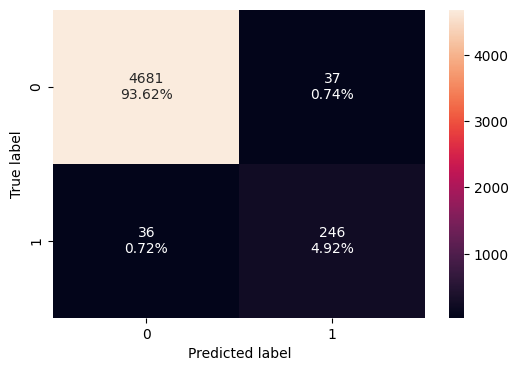

In [246]:
# Plot 'test' confusion matrix

print('Test Confusion Matrix\n')
confusion_matrix_sklearn(model_9, X_test, y_test)

**Observations:**

- Out of 282 actual failures in the unseen test data, the model successfully caught 246 (True Positives), missing only 36 (0.72%) (False Negatives). This translates to the excellent 0.9322 Test Recall.

- This model flagged 37(0.74%) healthy instances as failures (False Positives) out of over 4,700 actual non-failures. This confirms the strong 0.9308 Test Precision.

Overall this model generalised well. The model learned genuine, underlying rules rather than memorizing the training data, making it more stable.

## Actionable Insights & Recommendations

### Actionable Insights



1. **Exceptional Failure Detection Rate:**
    - The **final model(Model 9)** achieved an outstanding Test Recall of 0.9322, successfully identifying 246 out of the 282 actual generator failures in the unseen test data.
    - This proves the model is highly capable of alerting the business to impending breakdowns before they result in catastrophic physical damage and massive operational downtime.

2. **Highly Efficient Resource Allocation:**
    - Out of more than 4700 healthy turbine instances, the model only flagged 37 incorrectly as failures (False Positives).
    - This low false alarm rate ensures that maintenance teams will not waste valuable labor hours on unnecessary routine inspections.

3. **Successful Handling of Imbalanced Data:**
    - The dataset featured a severe class imbalance, which naturally skews machine learning models toward predicting "no failure".
    - By effectively utilizing class weights, assigning a heavy weight to the minority failure class; the model successfully prioritized the detection of costly False Negatives over misleading overall accuracy metrics.

4. **Optimal Deep Learning Architecture:**
    - The iterative approach proved that moving from an SGD optimizer to an Adam optimizer significantly boosted both Recall and Precision by better navigating the complex sensor data.
    - Furthermore, introducing Dropout layers (at 30% and 10% rates) was highly effective at regularizing the model and closing the generalization gap between training and validation sets.


5. **Proactive Downtime Scheduling:**
    - Sudden, catastrophic failures can happen at any time, including during peak wind seasons when turbine downtime costs the most in lost revenue.
    - By predicting failures in advance, operations managers can purposefully schedule maintenance during low-wind periods or off-peak energy demand hours, maximizing overall energy production and revenue.

7. **Validation of AI ROI (Return on Investment):**
    - The model's test performance provides a direct framework for calculating financial ROI.
    - The business can quantify the exact savings by multiplying the 246 averted catastrophic failures (True Positives) by the cost of a full generator replacement and lost downtime.
    - Subtracting the minor cost of the 37 unnecessary inspections (False Positives) from this figure will clearly demonstrate the immense financial value of this machine learning initiative to stakeholders.

8. **Scalability of the Solution:**
    - The final model proved its robust generalization capabilities across a substantial dataset (trained on 20000 instances and validated/tested on 5000 unseen instances).
    - This proves the architecture is stable and ready to be scaled fleet-wide across all ReneWind turbine farms, standardizing maintenance protocols company-wide.

### Business Recommendations

1. **Shift to Predictive Maintenance (PdM):**
    - ReneWind should begin integrating this Neural Network into the live sensor infrastructure of the wind turbines.
    - Transitioning from scheduled/reactive maintenance to a predictive strategy driven by this model will drastically reduce the costs associated with complete generator replacements.

2. **Deploy a Real-Time Monitoring Dashboard:**
    - ReneWind should implement a live dashboard to track the Neural Network's continuous predictions.
    - This system must include automated alerts that instantly trigger maintenance workflows when a generator is flagged as high-risk, ensuring rapid, proactive responses.

3. **Deep Dive into Missed Failures:**
    - The model missed 36 actual failures (False Negatives) in the test set. The engineering and data science teams should isolate these 36 instances and analyze their sensor logs.
    - Understanding why the model missed them could reveal the need for new engineered features, different sensor placements, or specific edge-case behaviors.

4. **Establish a Continuous Learning Pipeline:**
    - As turbine hardware ages and sensors degrade over time, the data distribution will experience "drift."
    - To maintain the excellent ~93% Recall rate, ReneWind should set up an automated pipeline to periodically retrain the Neural Network using newly verified operational data.



### Conclusion

The objective of this project was to transition ReneWind from a reactive maintenance approach to an AI-driven Predictive Maintenance strategy.

By leveraging deep learning, we successfully developed a highly sensitive early-warning system capable of identifying impending wind turbine generator failures using ciphered sensor data.

To achieve this, we overcame a severe class imbalance through specialized Artificial Neural Network (ANN) architectures, Adam optimization, and class weighting, ensuring the model prioritizes catching costly breakdowns over raw accuracy.

As a result, the final model achieved an outstanding Test Recall of 93.22%. It successfully identified 246 of 282 actual failures in unseen test data, while maintaining an incredibly low false alarm rate (flagging only 37 healthy instances out of over 4,700).

By deploying this model and following the recommended real-time monitoring and retraining loops, ReneWind is positioned to significantly reduce catastrophic equipment loss, minimize operational downtime, and maximize the overall profitability of their wind energy generation.